In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
import pickle
import random
from random import randint
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker

import statistics
from statistics import median
import tqdm
from tqdm import tqdm

import networkx as nx
from networkx import draw_networkx


from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import DataStructs

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.utils import from_smiles
from torch_geometric.data import Data, Dataset, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GraphConv, GCNConv, GATConv, GINConv, SAGEConv, TransformerConv, GINEConv
from torch_geometric.nn import BatchNorm, GraphNorm, MeanSubtractionNorm, LayerNorm, MessageNorm

import optuna

from contextlib import nullcontext

from all_functions import get_node_labels, process_predicted_boundaries_to_substructure_labels, remove_stereo, process_boundaries_to_substructure_labels, boundary_ligand_nodes_v2
from all_functions import make_graph_with_pos, get_substructure_smiles_function, MaxCommonSubstructure_maxatoms, process_predicted_nodes_to_substructure_labels, substructure_split_sort, prepare_data_set, mol_to_simple_graph, graph_descriptor #mol_to_simple_graph, graph_to_mol
from all_functions import get_girvan_newman_encoding
from all_functions import find_connected_ring_systems, get_components_from_ring_systems, get_murcko_bonds, find_intercomponent_bonds
from all_functions import get_boundary_bonds, format_tuple_bonds_to_COO, get_bond_labels, find_non_ring_bonds
from all_functions import get_substructure_smiles_function_v2
from all_functions import compute_countMorgFP, draw_molecule_with_highlighted_atoms, draw_molecule_with_highlighted_bonds

#from all_functions import redefine_outlier_nodes, consolidate_clusters

/home/knkn308/.conda/envs/env-protac-toolkit/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: cannot import name 'get_node_labels' from 'all_functions' (/projects/cc/kallberg_knkn308/Code/PROTAC-Splitter/notebooks/GNN/all_functions.py)

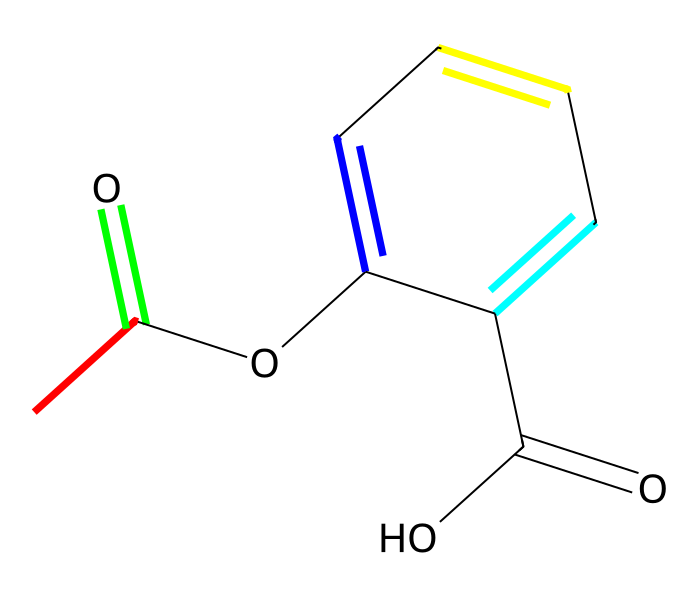

In [2]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG, display

def draw_molecule_with_highlighted_bonds(mol, bonds_to_highlight, highlight_bond_colors):
    """
    Draws a molecule with specified bonds highlighted in specified colors.
   
    Parameters:
    - mol (rdkit.Chem.Mol): An RDKit molecule object.
    - bonds_to_highlight (list): List of bond indices to highlight.
    - highlight_bond_colors (dict): Dictionary mapping bond indices to colors (tuples of RGB values).
    """
    # Initialize drawer
    d2d = rdMolDraw2D.MolDraw2DSVG(350*2, 300*2)
   
    # Set drawing options
    d2d.drawOptions().useBWAtomPalette()
    d2d.drawOptions().continuousHighlight = False
    d2d.drawOptions().highlightBondWidthMultiplier = 8
   
    # Prepare highlightBondColors parameter
    bond_colors = {}
    for idx, color in highlight_bond_colors.items():
        if idx in bonds_to_highlight:
            bond_colors[idx] = color

    # Draw the molecule with highlights
    d2d.DrawMolecule(mol,
                     highlightAtoms=[],
                     highlightBonds=bonds_to_highlight,
                     highlightBondColors=bond_colors)
    d2d.FinishDrawing()
   
    # Convert drawing to image and display
    svg = d2d.GetDrawingText()
    display(SVG(svg.replace('svg:','')))

# Aspirin SMILES string
smiles = 'CC(=O)Oc1ccccc1C(=O)O'
mol = Chem.MolFromSmiles(smiles)

# Choose some bonds to highlight, Aspirin has 11 bonds, let's highlight a few with different colors
bonds_to_highlight = [0, 1, 4, 6, 8]  # Example bond indices, adjust based on the molecule structure
# Assigning colors to the bonds we chose to highlight
highlight_bond_colors = {0: (1,0,0), 1: (0,1,0), 4: (0,0,1), 6: (1,1,0), 8: (0,1,1)}

draw_molecule_with_highlighted_bonds(mol, bonds_to_highlight, highlight_bond_colors)

In [ ]:
def viz_bonds(smi, target_bonds):

        from rdkit import Chem
        from rdkit.Chem import Draw
        from rdkit.Chem.Draw import rdMolDraw2D
        from IPython.display import SVG

        def draw_molecule_with_highlighted_bonds(mol, bonds_to_highlight):
            """
            Draws a molecule with specified atoms and bonds highlighted.
        
            Parameters:
            - smiles (str): SMILES string for the molecule.
            - atoms_to_highlight (set): Set of atom indices to highlight.
            - bonds_to_highlight (list): List of bond indices to highlight.
            - highlight_bond_colors (dict): Dictionary mapping bond indices to colors.
            """
            # Create molecule from SMILES
        
            # Initialize drawer
            d2d = Draw.rdMolDraw2D.MolDraw2DSVG(350*2, 300*2)
        
            # Set drawing options
            d2d.drawOptions().useBWAtomPalette()
            d2d.drawOptions().continuousHighlight = False
            d2d.drawOptions().highlightBondWidthMultiplier = 24
            d2d.drawOptions().setHighlightColour((1, 0, 0))
            d2d.drawOptions().fillHighlights = False
        
            # Draw the molecule with highlights
            d2d.DrawMolecule(mol,
                            highlightAtoms=[],
                            highlightBonds=bonds_to_highlight)
            d2d.FinishDrawing()
        
            # Convert drawing to image and display
            svg = d2d.GetDrawingText()
            display(SVG(svg.replace('svg:','')))


        
        #smi = train_set_pub[protac_idx].smiles
        mol = Chem.MolFromSmiles(smi)
        #mol = train_set_pub.mols[protac_idx]

        #display(train_set_pub.boundary_bonds[protac_idx])
        #display(train_set_pub.splittable_bonds[protac_idx])

        bond_idx_list = []

        for bond_idx, bond in enumerate(mol.GetBonds()):
            if bond_idx == 21: #39:
                pass
            start_atom_idx = bond.GetBeginAtomIdx()
            end_atom_idx = bond.GetEndAtomIdx()

            #target_bonds = train_set_pub[protac_idx].boundary_bonds_coo.tolist()

            enumerated_bond_is_in_target_bonds = False
            if start_atom_idx in target_bonds[0]:
                if end_atom_idx in target_bonds[1]:
                    start_atom_indices = set([i for i in range(len(target_bonds[0])) if target_bonds[0][i] == start_atom_idx])
                    end_atom_indices = set([i for i in range(len(target_bonds[1])) if target_bonds[1][i] == end_atom_idx])
                    shares_indices = start_atom_indices.intersection(end_atom_indices)
                    if shares_indices: #target_bonds[0].index(start_atom_idx) == target_bonds[1].index(end_atom_idx):             #om det finns flera index för samma atom så tar .index bara det första! Behöver hämta alla index och se om något är lika
                        enumerated_bond_is_in_target_bonds = True
            if start_atom_idx in target_bonds[1]:
                if end_atom_idx in target_bonds[0]:
                    start_atom_indices = set([i for i in range(len(target_bonds[1])) if target_bonds[1][i] == start_atom_idx])
                    end_atom_indices = set([i for i in range(len(target_bonds[0])) if target_bonds[0][i] == end_atom_idx])
                    shares_indices = start_atom_indices.intersection(end_atom_indices)
                    if shares_indices: #target_bonds[1].index(start_atom_idx) == target_bonds[0].index(end_atom_idx):
                        enumerated_bond_is_in_target_bonds = True

            if enumerated_bond_is_in_target_bonds:
                bond_idx_list.append(bond_idx)

        draw_molecule_with_highlighted_bonds(mol, bond_idx_list)

In [ ]:
from IPython.display import clear_output
import time

In [ ]:
display(mol, display_id=0)

In [ ]:
splittable_bonds = find_non_ring_bonds(mol, ring_systems, exclude_bonds_connected_to_atoms_with_1_bond=True, datatype="dict")
splittable_bond_idx = list(splittable_bonds.keys())

In [ ]:
protac_pub_trainset_df = pd.read_csv('../../data/augmented/protac_pub_trainset3720_randBonds.csv')
protac_smiles_train = protac_pub_trainset_df["PROTAC SMILES"].to_list()

In [ ]:

from rdkit.Chem import rdchem

all_splits_for_all_protacs = {}
for smiles in tqdm(protac_smiles_train):
    mol = Chem.MolFromSmiles(smiles)
    for atom in mol.GetAtoms():
        atom.SetProp('originalIdx', str(atom.GetIdx()))         
    ring_systems = find_connected_ring_systems(mol)
    splittable_bonds_list = find_non_ring_bonds(mol, ring_systems, exclude_bonds_connected_to_atoms_with_1_bond=True, datatype="list")
    all_splits_for_all_protacs[smiles] = get_all_splits_from_all_splittable_bonds(mol, splittable_bonds_list)
            


In [ ]:
x =list(all_splits_for_all_protacs.keys())
smiles = x[0]
allowed_splits = all_splits_for_all_protacs[smiles]
mol = Chem.MolFromSmiles(smiles)
draw_molecule_with_highlighted_atoms(mol, allowed_splits[37])

In [ ]:
def get_all_splits_from_all_splittable_bonds(mol, splittable_bonds_list):

    # get all splittable bonds in the format of a list of tuples containing start and end atoms of these bonds
    # split each of these bonds and find the resulting atoms indices
    # add hydrogens to make a chemically valid molecules, get the original node idx, remove hydrogens and restore the editable molecule
    # store all indices of the all splits

    hydrogen_atom = rdchem.Atom(1)
    hydrogen_atom.SetProp('originalIdx', str(-1))    
    bond_to_num_Hs_to_add = {rdchem.BondType.SINGLE: 1,
                             rdchem.BondType.DOUBLE: 2,
                             rdchem.BondType.TRIPLE: 3}

    emol = Chem.EditableMol(mol)
    atom_indices_all_smallest_frags = {}
    for chronological_bond_idx, (start_atom_idx, end_atom_idx) in enumerate(splittable_bonds_list):

        bond = mol.GetBondBetweenAtoms(start_atom_idx, end_atom_idx)
        #bond_idx = bond.GetIdx()

        bondtype = bond.GetBondType()
        emol.RemoveBond(start_atom_idx, end_atom_idx)

        H_atoms_idx=[]
        for bond_atom_idx in (start_atom_idx, end_atom_idx):
            num_Hs_to_add = bond_to_num_Hs_to_add[bondtype]
            for _ in range(num_Hs_to_add):
                H_idx = emol.AddAtom(hydrogen_atom)
                H_atoms_idx.append(H_idx)
                emol.AddBond(bond_atom_idx, H_idx, order = rdchem.BondType.SINGLE)
        split_mol = emol.GetMol() 
        split_mol_frags = Chem.GetMolFrags(split_mol,asMols=True)
            
        if split_mol_frags[0].GetNumAtoms() < split_mol_frags[1].GetNumAtoms() :
            smallest_frag = split_mol_frags[0]
        else:
            smallest_frag = split_mol_frags[1]

        original_atom_idx_smallest_frag = []
        for atom in smallest_frag.GetAtoms():
            original_atom_idx = int(atom.GetProp('originalIdx'))
            if original_atom_idx > -1:
                original_atom_idx_smallest_frag.append(original_atom_idx)
        atom_indices_all_smallest_frags[chronological_bond_idx] = original_atom_idx_smallest_frag
            
        for H_atom_idx in sorted(H_atoms_idx, reverse=True):
            emol.RemoveAtom(H_atom_idx)
        emol.AddBond(start_atom_idx, end_atom_idx, order = bondtype)
    
    return atom_indices_all_smallest_frags
         

In [ ]:
all_splits_for_all_protacs = {}
for smiles in tqdm(protac_smiles_train):
    mol = Chem.MolFromSmiles(smiles)
    splittable_bonds = find_non_ring_bonds(mol, ring_systems, exclude_bonds_connected_to_atoms_with_1_bond=True, datatype="list")
    atom_indices_all_smallest_frags = get_all_splits_from_all_splittable_bonds(mol)
    all_splits_for_all_protacs[smiles] = atom_indices_all_smallest_frags



In [ ]:

all_splits_for_all_protacs[smiles]


In [ ]:
from typing import Callable, List, Union

import torch
from torch import Tensor

from torch_geometric.nn import GCNConv, TopKPooling
from torch_geometric.nn.resolver import activation_resolver
from torch_geometric.typing import OptTensor, PairTensor
from torch_geometric.utils import (
    add_self_loops,
    remove_self_loops,
    to_torch_csr_tensor,
)
from torch_geometric.utils.repeat import repeat


class GraphUNet(torch.nn.Module):
    r"""The Graph U-Net model from the `"Graph U-Nets"
    <https://arxiv.org/abs/1905.05178>`_ paper which implements a U-Net like
    architecture with graph pooling and unpooling operations.

    Args:
        in_channels (int): Size of each input sample.
        hidden_channels (int): Size of each hidden sample.
        out_channels (int): Size of each output sample.
        depth (int): The depth of the U-Net architecture.
        pool_ratios (float or [float], optional): Graph pooling ratio for each
            depth. (default: :obj:`0.5`)
        sum_res (bool, optional): If set to :obj:`False`, will use
            concatenation for integration of skip connections instead
            summation. (default: :obj:`True`)
        act (torch.nn.functional, optional): The nonlinearity to use.
            (default: :obj:`torch.nn.functional.relu`)
    """
    def __init__(
        self,
        in_channels: int,
        hidden_channels: int,
        out_channels: int,
        depth: int,
        pool_ratios: Union[float, List[float]] = 0.5,
        sum_res: bool = True,
        act: Union[str, Callable] = 'relu',
    ):
        super().__init__()
        assert depth >= 1
        self.in_channels = in_channels
        self.hidden_channels = hidden_channels
        self.out_channels = out_channels
        self.depth = depth
        self.pool_ratios = repeat(pool_ratios, depth)
        self.act = activation_resolver(act)
        self.sum_res = sum_res

        channels = hidden_channels

        self.down_convs = torch.nn.ModuleList()
        self.pools = torch.nn.ModuleList()
        self.down_convs.append(GCNConv(in_channels, channels, improved=True))
        for i in range(depth):
            self.pools.append(TopKPooling(channels, self.pool_ratios[i]))
            self.down_convs.append(GCNConv(channels, channels, improved=True))

        in_channels = channels if sum_res else 2 * channels

        self.up_convs = torch.nn.ModuleList()
        for i in range(depth - 1):
            self.up_convs.append(GCNConv(in_channels, channels, improved=True))
        self.up_convs.append(GCNConv(in_channels, out_channels, improved=True))

        self.reset_parameters()

    def reset_parameters(self):
        r"""Resets all learnable parameters of the module."""
        for conv in self.down_convs:
            conv.reset_parameters()
        for pool in self.pools:
            pool.reset_parameters()
        for conv in self.up_convs:
            conv.reset_parameters()


    def forward(self, x: Tensor, edge_index: Tensor,
                batch: OptTensor = None) -> Tensor:
        """"""  # noqa: D419
        if batch is None:
            batch = edge_index.new_zeros(x.size(0))
        edge_weight = x.new_ones(edge_index.size(1))

        x = self.down_convs[0](x, edge_index, edge_weight)
        x = self.act(x)

        xs = [x]
        edge_indices = [edge_index]
        edge_weights = [edge_weight]
        perms = []

        for i in range(1, self.depth + 1):
            edge_index, edge_weight = self.augment_adj(edge_index, edge_weight,
                                                       x.size(0))
            x, edge_index, edge_weight, batch, perm, _ = self.pools[i - 1](
                x, edge_index, edge_weight, batch)

            x = self.down_convs[i](x, edge_index, edge_weight)
            x = self.act(x)

            if i < self.depth:
                xs += [x]
                edge_indices += [edge_index]
                edge_weights += [edge_weight]
            perms += [perm]

        for i in range(self.depth):
            j = self.depth - 1 - i

            res = xs[j]
            edge_index = edge_indices[j]
            edge_weight = edge_weights[j]
            perm = perms[j]

            up = torch.zeros_like(res)
            up[perm] = x
            x = res + up if self.sum_res else torch.cat((res, up), dim=-1)

            x = self.up_convs[i](x, edge_index, edge_weight)
            x = self.act(x) if i < self.depth - 1 else x

        return x


    def augment_adj(self, edge_index: Tensor, edge_weight: Tensor,
                    num_nodes: int) -> PairTensor:
        edge_index, edge_weight = remove_self_loops(edge_index, edge_weight)
        edge_index, edge_weight = add_self_loops(edge_index, edge_weight,
                                                 num_nodes=num_nodes)
        adj = to_torch_csr_tensor(edge_index, edge_weight,
                                  size=(num_nodes, num_nodes))
        adj = (adj @ adj).to_sparse_coo()
        edge_index, edge_weight = adj.indices(), adj.values()
        edge_index, edge_weight = remove_self_loops(edge_index, edge_weight)
        return edge_index, edge_weight

    def __repr__(self) -> str:
        return (f'{self.__class__.__name__}({self.in_channels}, '
                f'{self.hidden_channels}, {self.out_channels}, '
                f'depth={self.depth}, pool_ratios={self.pool_ratios})')

In [ ]:
from rdkit import Chem
from rdkit.Chem.rdMolHash import MolHash, HashFunction
from rdkit import Chem
from rdkit.Chem import rdFMCS, AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold

def anonymize_molecule(mol):
    """Anonymize the molecule using RDKit's MolHash with the AnonymousGraph hash function."""
    anon_smiles = MolHash(mol, HashFunction.AnonymousGraph)
    anon_mol = Chem.MolFromSmiles(anon_smiles)
    return anon_mol

def set_bonds_to_single(mol):
    modified_mol = Chem.RWMol(mol)
    # Iterate through all bonds and set them to single
    for bond in modified_mol.GetBonds():
        bond.SetBondType(Chem.BondType.SINGLE)
    return modified_mol

smi = 'COC(=O)CC1C2(C)C3=C(C)C(c4ccoc4CCOCCOCCOCCOCCOCCOCCNC(=O)c4ccc(NCOc5ccc(CC(=O)Nc6cc(C7CCC7)[nH]n6)cc5)cc4)CC3OC2C2OC(=O)C3(C)C=CC(=O)C1(C)C23' #'Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(F)CC2)C(C)(C)C)c(OCCCOCCCCNCCCOC(=O)NC(Nc2ncccn2)C(Cl)(Cl)Cl)c1' #CC1(c2nc3c(C(N)=O)cccc3[nH]2)CCCN1N1CC(N2CCN(c3ccc(Cl)c(N4CCC(=O)NC4=O)c3)CC2)C1' 
mol = Chem.MolFromSmiles(smi)
for atom in mol.GetAtoms():
    atom.SetProp('originalIdx', str(atom.GetIdx()))
scaffold = MurckoScaffold.GetScaffoldForMol(mol)

matching_atoms = mol.GetSubstructMatch(scaffold)


# Create a mapping of scaffold atom indices to original molecule atom indices
#index_mapping = {}
#for atom in scaffold.GetAtoms():
#    if atom in matching_atoms:
#        index_mapping[atom.GetIdx()] = int(atom.GetProp('originalIdx'))

print(matching_atoms)
display(mol)
display(scaffold)


In [ ]:
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG


# Highlight the matching atoms
d = rdMolDraw2D.MolDraw2DSVG(400, 400)  # Set the size of the image
rdMolDraw2D.PrepareAndDrawMolecule(d, mol, highlightAtoms=matching_atoms)
d.FinishDrawing()

# Display the image with highlighted atoms
svg = d.GetDrawingText()
display(SVG(svg.replace('svg:','')))
display()

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

def draw_molecule_with_highlighted_ring_systems(mol, ring_systems):
    """
    Draws the molecule with each connected ring system highlighted in a different color,
    using a predefined list of colors.
   
    Parameters:
    - mol (rdkit.Chem.Mol): The molecule to draw.
    - ring_systems (List[List[int]]): A list of lists, with each sublist containing the atom indices of a connected ring system.
    """
    # Initialize drawer
    drawer = rdMolDraw2D.MolDraw2DSVG(400*2, 400*2)
    drawer.drawOptions().padding = 0.2
   
    # Define a list of colors to use for highlighting
    # Colors are defined in RGB tuples
    colors = [(0.8, 0.1, 0.1), (0.1, 0.8, 0.1), (0.1, 0.1, 0.8), (0.8, 0.8, 0.1), (0.1, 0.8, 0.8), (0.8, 0.1, 0.8)]
   
    # Prepare highlight atoms and colors dictionaries
    highlight_atoms = {}
    highlight_atom_colors = {}
    
    #for atom in mol.GetAtoms():
    #    original_atom_idx = int(atom.GetProp('originalIdx'))
    #    for i, system in enumerate(ring_systems):
    #        color = colors[i % len(colors)]
    #        if original_atom_idx in system:
    #            highlight_atoms[original_atom_idx] = 1
    #            highlight_atom_colors[original_atom_idx] = color


    for i, system in enumerate(ring_systems):
        color = colors[i % len(colors)]  # Cycle through colors if there are more ring systems than colors
        for atom in system:
            highlight_atoms[atom] = 1  # Just a placeholder to indicate the atom should be highlighted
            highlight_atom_colors[atom] = color
   
    print(len(highlight_atom_colors))
    print(len(list(highlight_atoms.keys())))
    print(list(highlight_atoms.keys()))
    # Draw molecule with highlighted ring systems
    rdMolDraw2D.PrepareAndDrawMolecule(drawer, mol, highlightAtoms=list(highlight_atoms.keys()), highlightAtomColors=highlight_atom_colors)
    drawer.FinishDrawing()
   
    # Display the drawing
    svg = drawer.GetDrawingText()
    display(SVG(svg.replace('svg:', '')))


In [ ]:
from rdkit import Chem
from rdkit.Chem import rdChemReactions

def find_connected_ring_systems(mol):
    """
    Identifies each connected ring system in the molecule and returns them as a list of lists,
    where each sublist contains the indices of the atoms in one connected ring system.
   
    Parameters:
    - mol (rdkit.Chem.Mol): The molecule to analyze.
   
    Returns:
    - List[List[int]]: A list of lists, with each sublist containing the atom indices of a connected ring system.
    """
    # Find the ring systems
    ring_info = mol.GetRingInfo()
    ring_atoms = ring_info.AtomRings()
   
    # Initialize a list to keep track of which atoms belong to which ring system
    ring_systems = []

    # Check each ring against existing ring systems to find connections
    for ring in ring_atoms:
        found = False
        for system in ring_systems:
            # If the ring shares atoms with an existing system, it's connected
            if not set(ring).isdisjoint(system):
                system.update(ring)
                found = True
                break
        if not found:
            # If the ring isn't connected to existing systems, start a new one
            ring_systems.append(set(ring))
   
    # Convert sets back to lists for easier use later
    ring_systems = [list(system) for system in ring_systems]
   
    return ring_systems


In [ ]:
def merge_rings_if_sharing_at_least_2_atoms(sets):
    while True:
        did_merge = False # Flag to track if any merge occurred in this iteration.
        for i in range(len(sets)):
            if did_merge:
                break # If a merge occurred, restart from the beginning.
            for j in range(i + 1, len(sets)):
                if len(sets[i].intersection(sets[j])) > 1: # Check if two sets share 2 or more elements.
                    # Merge sets and update the list of sets.
                    sets[i] = sets[i].union(sets[j])
                    del sets[j] # Remove the merged set.
                    did_merge = True # Set the flag as true because a merge occurred.
                    break # Exit the loop to restart the process due to the modification of the list.
        if not did_merge:
            break # If no merges occurred in this iteration, exit the while loop.

    return sets

# Adjusting the example to ensure there are sets that share 2 or more elements for merging.
set_list_adjusted = [{1, 2, 3}, {3, 4, 5}, {4, 5, 6}, {7, 8}, {8, 9, 10}, {5, 6, 8, 9}, {7, 8}, {4, 5, 7,8 }]

# Re-run the function with the adjusted set list.
merged_sets_adjusted = merge_rings_if_sharing_at_least_2_atoms(set_list_adjusted)
display(merged_sets_adjusted)

In [ ]:
from rdkit import Chem
from collections import defaultdict

def get_components_from_ring_systems(mol, ring_systems):   
    """
    Expands each ring system in the molecule based on bond connectivity, ensuring atoms connected
    to multiple ring systems are not included.
    
    Parameters:
    - mol (Chem.Mol): RDKit molecule object.
    - ring_systems (List[List[int]]): Initial ring systems identified by find_connected_ring_systems.
    
    Returns:
    - List[Set[int]]: Expanded ring systems with additional connected atoms.
    """
    # Convert list of lists to list of sets for easier manipulation
    ring_systems = [set(system) for system in ring_systems]
    
    ring_systems = merge_rings_if_sharing_at_least_2_atoms(ring_systems)

    # Create a mapping from atoms to their respective ring systems
    atom_to_systems = defaultdict(set)
    for i, system in enumerate(ring_systems):
        for atom_idx in system:
            atom_to_systems[atom_idx].add(i)

    # Work on a copy of the molecule to avoid altering the original
    editable_mol = Chem.RWMol(mol)

    for system_idx, original_system in enumerate(ring_systems):
        if system_idx == 2:
            pass
        system_atoms_to_add = set()

        # Make a temporary copy of the original system for safe iteration
        temp_system = set(original_system)

        for atom_idx in temp_system:
            atom = editable_mol.GetAtomWithIdx(atom_idx)
            neighbors = atom.GetNeighbors()

            # Check each neighbor to see if it forms a bridge to another ring system
            for neighbor in neighbors:
                neighbor_idx = neighbor.GetIdx()
                # Skip if neighbor is in the same ring system
                if neighbor_idx in temp_system:
                    continue

                # Cut the bond and check connectivity to other systems
                bond = editable_mol.GetBondBetweenAtoms(atom_idx, neighbor_idx)
                if bond:  # If there's a bond connecting to a potential new atom
                    editable_mol.RemoveBond(atom_idx, neighbor_idx)
                    new_fragment = Chem.GetMolFrags(editable_mol, asMols=True, sanitizeFrags=False)
                    
                    # Determine if the neighbor belongs exclusively to this system
                    #frag_exclusive_to_this_system = None
                    for frag in new_fragment:
                        #if system_idx == 2:
                        #    display(frag)
                        exclusive_to_this_system = True
                        frag_atom_indices = set(int(atom.GetProp('originalIdx')) for atom in frag.GetAtoms())
                        # If the fragment contains atoms from other ring systems, it's not exclusive
                        if not frag_atom_indices.isdisjoint(atom_to_systems.keys()) and not frag_atom_indices <= temp_system:
                            exclusive_to_this_system = False
                            continue
                        if exclusive_to_this_system:
                            system_atoms_to_add.update(frag_atom_indices)
                            #system_atoms_to_add.update(frag_atom_indices)

                    # Rebuild the molecule to restore the bond
                    editable_mol = Chem.RWMol(mol)

        # Update the original system with new atoms after checking all bonds
        original_system.update(system_atoms_to_add)

    #print(ring_systems)
    
    #print(ring_systems)

    return [list(system) for system in ring_systems]




In [ ]:

# Example usage
connected_ring_systems = find_connected_ring_systems(mol)

# Print the atom indices for each connected ring system
for i, system in enumerate(connected_ring_systems, start=1):
    print(f"Ring System {i}: {system}")

#draw_molecule_with_highlighted_ring_systems(scaffold, connected_ring_systems)
components = get_components_from_ring_systems(mol, connected_ring_systems)
for i, component in enumerate(components, start=1):
    print(f"Ring System {i}: {component}")
draw_molecule_with_highlighted_ring_systems(mol, components)

In [ ]:
import pandas as pd
from tqdm import tqdm

In [ ]:
def find_intercomponent_bonds(mol, components, allowed_bonds='all'):
    """
    Identifies bonds that are not contained within the same component.
    
    Parameters:
    - mol (Chem.Mol): The RDKit molecule object.
    - components (List[List[int]]): A list of components, where each component is a list of atom indices.
    
    Returns:
    - List[Tuple[int, int]]: A list of tuples, where each tuple contains the indices of atoms forming an intercomponent bond.
    """
    # Convert the list of components into a dictionary for faster lookup
    atom_to_component = {}
    for component_idx, component in enumerate(components):
        for atom_idx in component:
            atom_to_component[atom_idx] = component_idx

    # List to store bonds that connect different components or atoms not in any component
    intercomponent_bonds = []
    bond_idx_list = []

    # Iterate through all bonds in the molecule
    for bond in mol.GetBonds():
        start_atom_idx = bond.GetBeginAtomIdx()
        end_atom_idx = bond.GetEndAtomIdx()

        # Determine the component of each atom in the bond
        start_component = atom_to_component.get(start_atom_idx, None)
        end_component = atom_to_component.get(end_atom_idx, None)

        # Check if bond connects different components or outside any component
        if start_component is None or end_component is None or start_component != end_component:
            start_atom_originalidx = mol.GetAtomWithIdx(start_atom_idx).GetProp('originalIdx')
            end_atom_originalidx = mol.GetAtomWithIdx(end_atom_idx).GetProp('originalIdx')
            if allowed_bonds != 'all':
                if (start_atom_originalidx, end_atom_originalidx) in allowed_bonds or (end_atom_originalidx, start_atom_originalidx) in allowed_bonds:
                    intercomponent_bonds.append((start_atom_originalidx, end_atom_originalidx))
                    bond_idx_list.append(bond.GetIdx())
            else:
                intercomponent_bonds.append((start_atom_originalidx, end_atom_originalidx))
                bond_idx_list.append(bond.GetIdx())

    return intercomponent_bonds, bond_idx_list

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

def draw_molecule_with_highlighted_bonds(mol, bonds_to_highlight):
    """
    Draws a molecule with specified atoms and bonds highlighted.
   
    Parameters:
    - smiles (str): SMILES string for the molecule.
    - atoms_to_highlight (set): Set of atom indices to highlight.
    - bonds_to_highlight (list): List of bond indices to highlight.
    - highlight_bond_colors (dict): Dictionary mapping bond indices to colors.
    """
    # Create molecule from SMILES
   
    # Initialize drawer
    d2d = Draw.rdMolDraw2D.MolDraw2DSVG(350*2, 300*2)
   
    # Set drawing options
    d2d.drawOptions().useBWAtomPalette()
    d2d.drawOptions().continuousHighlight = False
    d2d.drawOptions().highlightBondWidthMultiplier = 24
    d2d.drawOptions().setHighlightColour((0, 0, 1))
    d2d.drawOptions().fillHighlights = False
   
    # Draw the molecule with highlights
    d2d.DrawMolecule(mol,
                    highlightAtoms=[],
                     highlightBonds=bonds_to_highlight)
    d2d.FinishDrawing()
   
    # Convert drawing to image and display
    svg = d2d.GetDrawingText()
    display(SVG(svg.replace('svg:','')))

def draw_molecule_with_highlighted_atoms(mol, atoms_to_highlight):
    """
    Draws a molecule with specified atoms and bonds highlighted.
   
    Parameters:
    - smiles (str): SMILES string for the molecule.
    - atoms_to_highlight (set): Set of atom indices to highlight.
    - bonds_to_highlight (list): List of bond indices to highlight.
    - highlight_bond_colors (dict): Dictionary mapping bond indices to colors.
    """
    # Create molecule from SMILES
   
    # Initialize drawer
    d2d = Draw.rdMolDraw2D.MolDraw2DSVG(350*2, 300*2)
   
    # Set drawing options
    d2d.drawOptions().useBWAtomPalette()
    d2d.drawOptions().continuousHighlight = False
    d2d.drawOptions().highlightBondWidthMultiplier = 24
    d2d.drawOptions().setHighlightColour((0, 0, 1))
    d2d.drawOptions().fillHighlights = False
   
    # Draw the molecule with highlights
    d2d.DrawMolecule(mol,
                    highlightAtoms=atoms_to_highlight)
    d2d.FinishDrawing()
   
    # Convert drawing to image and display
    svg = d2d.GetDrawingText()
    display(SVG(svg.replace('svg:','')))

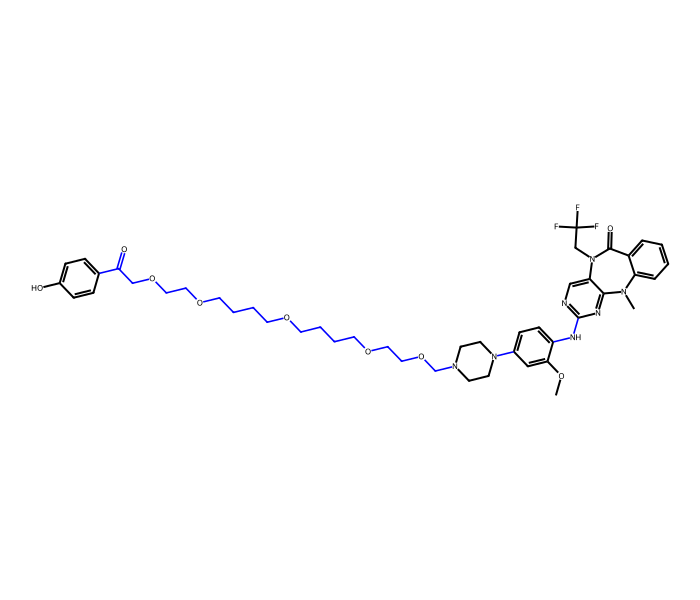

In [145]:
smi = 'COc1cc(N2CCN(COCCOCCCCOCCCCOCCOCC(=O)c3ccc(O)cc3)CC2)ccc1Nc1ncc2c(n1)N(C)c1ccccc1C(=O)N2CC(F)(F)F'#'Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)C2(F)CC2)C(C)(C)C)c(OCCCOCCCCNCCCOC(=O)NC(Nc2ncccn2)C(Cl)(Cl)Cl)c1'
mol = Chem.MolFromSmiles(smi)
for atom in mol.GetAtoms():
    atom.SetProp('originalIdx', str(atom.GetIdx()))
ring_systems = find_connected_ring_systems(mol)
components = get_components_from_ring_systems(mol, ring_systems)
intercomponent_bonds, bond_idx_list = find_intercomponent_bonds(mol, components)
#draw_molecule_with_highlighted_ring_systems(mol, components)
draw_molecule_with_highlighted_bonds(mol, bond_idx_list)


In [ ]:
def get_murcko_bonds(scaffold):
    murcko_bond_list = []
    for bond in scaffold.GetBonds():
        start_atom_idx = bond.GetBeginAtomIdx()
        end_atom_idx = bond.GetEndAtomIdx()
        start_atom_originalidx = scaffold.GetAtomWithIdx(start_atom_idx).GetProp('originalIdx')
        end_atom_originalidx = scaffold.GetAtomWithIdx(end_atom_idx).GetProp('originalIdx')
        murcko_bond_list.append((start_atom_originalidx, end_atom_originalidx))
    return murcko_bond_list


In [ ]:
protac_pub_trainset_df = pd.read_csv('../../data/augmented/protac_pub_trainset3720.csv')
protac_pub_trainset_df["PROTAC SMILES"][0]

In [ ]:

#mol = Chem.MolFromSmiles('N#CCC1CN(c2nc(OCC3CCCN3CCCOCCOCCOCC(=O)Nc3ccc4c(c3)C(=O)N(C3CCC(=O)NC3=O)C4=O)nc3c2CCN(c2cccc4cccc(Cl)c24)C3)CCN1C(=O)C(C#N)=CC1CC1')
#scaffold = MurckoScaffold.GetScaffoldForMol(mol)
murcko_bond_list = get_murcko_bonds(scaffold=scaffold)


In [ ]:
def get_bond_labels(splittable_bonds, boundary_bonds):

    poi_label = 1 #choose with the forward method architecture in mind. If cosine angle => both may need to be equal to 1, negative values I guess will give an "unstable" prediction if it isnt perfectly confident. If feed the pair of nodes to a neural network, then I can choose anything
    e3_label = -1

    bond_labels = [torch.zeros(len(splittable_bonds_i),1) for splittable_bonds_i in splittable_bonds]

    for protac_idx, splittable_bonds_protac, boundary_bonds_protac in enumerate(zip(splittable_bonds, boundary_bonds)):
        poi_bond = boundary_bonds_protac[0]
        poi_bond_mirrored = (poi_bond[1], poi_bond[0])
        e3_bond = boundary_bonds_protac[1]
        e3_bond_mirrored = (e3_bond[1], e3_bond[0])

        

        for bond_idx, splittable_bond in enumerate(splittable_bonds_protac):
            if poi_bond == splittable_bond or poi_bond_mirrored == splittable_bond:
                bond_labels[protac_idx][bond_idx] = poi_label
            if e3_bond == splittable_bond or e3_bond_mirrored == splittable_bond:
                bond_labels[protac_idx][bond_idx] = e3_label

    return bond_labels





In [ ]:
def find_non_ring_bonds(mol, ring_systems, exclude_bonds_connected_to_atoms_with_1_bond):
    non_ring_bonds_dict = {}

    #non_ring_bonds_idx = []
    #non_ring_bonds = []
    for bond_idx, bond in enumerate(mol.GetBonds()):
        start_atom_idx = bond.GetBeginAtomIdx()
        end_atom_idx = bond.GetEndAtomIdx()

        for system in ring_systems:
            ring_bond = False
            if start_atom_idx in system and end_atom_idx in system:
                ring_bond = True
                break
        
        if ring_bond is False:
            exclude_bond = False

            if exclude_bonds_connected_to_atoms_with_1_bond:
                start_atom = mol.GetAtomWithIdx(start_atom_idx)
                end_atom = mol.GetAtomWithIdx(end_atom_idx)

                start_atom_num_bonds = start_atom.GetTotalDegree() - start_atom.GetTotalNumHs()
                end_atom_num_bonds = end_atom.GetTotalDegree() - end_atom.GetTotalNumHs()
                
                if start_atom_num_bonds == 1 or end_atom_num_bonds == 1:
                    exclude_bond = True

            if not exclude_bond:
                non_ring_bonds_dict[bond_idx] = (start_atom_idx, end_atom_idx)
            
    return non_ring_bonds_dict

In [ ]:
def find_ring_bonds(mol, ring_systems):
    ring_bonds_dict = {}
    
    #ring_bonds_idx = []
    #ring_bonds = []
    for bond_idx, bond in enumerate(mol.GetBonds()):
        start_atom_idx = bond.GetBeginAtomIdx()
        end_atom_idx = bond.GetEndAtomIdx()

        for system in ring_systems:
            ring_bond = False
            if start_atom_idx in system and end_atom_idx in system:
                ring_bond = True
                break
        if ring_bond is True:
            #ring_bonds_idx.append(bond_idx)
            #ring_bonds.append((start_atom_idx, end_atom_idx))
            ring_bonds_dict[bond_idx] = (start_atom_idx, end_atom_idx)
    
    
    return ring_bonds_dict

In [ ]:
def find_atoms_with_1_bond(mol):
    atoms_with_1_bond = []
    for atom in mol.GetAtoms():
        atom_num_bonds = atom.GetTotalDegree() - atom.GetTotalNumHs()
        if atom_num_bonds == 1:
            original_idx = int(atom.GetProp('originalIdx'))
            atoms_with_1_bond.append(original_idx)
    
    return atoms_with_1_bond

In [ ]:
def find_bonds_with_atoms_that_only_have_1_bond(mol):
    atoms_with_1_bond = find_atoms_with_1_bond(mol)
    
    bonds_with_atoms_that_only_have_1_bond = []
    bonds_with_atoms_that_only_have_1_bond_idx = []
    for bond_idx, bond in enumerate(mol.GetBonds()):
        start_atom_idx = bond.GetBeginAtomIdx()
        end_atom_idx = bond.GetEndAtomIdx()

        if start_atom_idx in atoms_with_1_bond or end_atom_idx in atoms_with_1_bond:
            #meaning, this bond is conneced to an atom with only 1 bonds (this bond)

            bonds_with_atoms_that_only_have_1_bond.append((start_atom_idx,end_atom_idx))
            bonds_with_atoms_that_only_have_1_bond_idx.append(bond_idx)

    return bonds_with_atoms_that_only_have_1_bond, bonds_with_atoms_that_only_have_1_bond_idx

In [ ]:
def find_bonds_not_connected_to_atoms_with_only_1_bond(mol):
    _, bonds_with_atoms_that_only_have_1_bond_idx = find_bonds_with_atoms_that_only_have_1_bond(mol)

    bonds_not_connected_to_atoms_with_only_1_bond = []
    bonds_not_connected_to_atoms_with_only_1_bond_idx = []

    for bond_idx, bond in enumerate(mol.GetBonds()):
        if bond_idx not in bonds_with_atoms_that_only_have_1_bond_idx:
            start_atom_idx = bond.GetBeginAtomIdx()
            end_atom_idx = bond.GetEndAtomIdx()
            bonds_not_connected_to_atoms_with_only_1_bond_idx.append(bond_idx)
            bonds_not_connected_to_atoms_with_only_1_bond.append((start_atom_idx, end_atom_idx))

    return bonds_not_connected_to_atoms_with_only_1_bond, bonds_not_connected_to_atoms_with_only_1_bond_idx

In [ ]:


print(atoms_with_1_bond)

In [ ]:
smi = 'CC(C)CC(NC(=O)CCCc1ccccc1)C(=O)NCC(=O)COCCOCCOCCNC(=O)CC(=O)NO'   #'CNC(C)C(=O)NC1CCOC2CC(C)(C)C(C(=O)NC3CCCc4cc(CCNC(=O)Cc5ccc(-c6ncc(N7CCC(C)(N)CC7)nc6N)c(Cl)c5Cl)ccc43)N2C1=O' #'CC(C)CC(NC(=O)CCCc1ccccc1)C(=O)NCC(=O)COCCOCCOCCNC(=O)CC(=O)NO'  #'COC(=O)CC1C2(C)C3=C(C)C(c4ccoc4CCOCCOCCOCCOCCOCCOCCNC(=O)c4ccc(NCOc5ccc(CC(=O)Nc6cc(C7CCC7)[nH]n6)cc5)cc4)CC3OC2C2OC(=O)C3(C)C=CC(=O)C1(C)C23' #'Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NCCOCCOCCOCCOCCC(=O)COc2c(F)cc(N3C(=S)N(c4ccc(C#N)c(C(F)(F)F)c4)C(=O)C3(C)C)cc2F)C(C)C)cc1'
mol = Chem.MolFromSmiles(smi)
for atom in mol.GetAtoms():
    atom.SetProp('originalIdx', str(atom.GetIdx()))
scaffold = MurckoScaffold.GetScaffoldForMol(mol)
ring_systems = find_connected_ring_systems(mol)
ring_systems_atoms = sum(ring_systems, [])
#draw_molecule_with_highlighted_atoms(mol, ring_systems_atoms)

ring_bonds_dict = find_non_ring_bonds(mol, ring_systems, exclude_bonds_connected_to_atoms_with_1_bond=True)



bonds_with_atoms_that_only_have_1_bond, bonds_with_atoms_that_only_have_1_bond_idx = find_bonds_with_atoms_that_only_have_1_bond(mol)
bonds_not_connected_to_atoms_with_only_1_bond, bonds_not_connected_to_atoms_with_only_1_bond_idx = find_bonds_not_connected_to_atoms_with_only_1_bond(mol)


draw_molecule_with_highlighted_bonds(mol, ring_bonds_dict.keys())


In [ ]:
list(ring_bonds_dict.values())

In [ ]:
smi = 'CC(C)CC(NC(=O)CCCc1ccccc1)C(=O)NCC(=O)COCCOCCOCCNC(=O)CC(=O)NO'  #'COC(=O)CC1C2(C)C3=C(C)C(c4ccoc4CCOCCOCCOCCOCCOCCOCCNC(=O)c4ccc(NCOc5ccc(CC(=O)Nc6cc(C7CCC7)[nH]n6)cc5)cc4)CC3OC2C2OC(=O)C3(C)C=CC(=O)C1(C)C23' #'Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NCCOCCOCCOCCOCCC(=O)COc2c(F)cc(N3C(=S)N(c4ccc(C#N)c(C(F)(F)F)c4)C(=O)C3(C)C)cc2F)C(C)C)cc1'
mol = Chem.MolFromSmiles(smi)
for atom in mol.GetAtoms():
    atom.SetProp('originalIdx', str(atom.GetIdx()))
scaffold = MurckoScaffold.GetScaffoldForMol(mol)
ring_systems = find_connected_ring_systems(mol)
components = get_components_from_ring_systems(mol, ring_systems)
murcko_bond_list = get_murcko_bonds(scaffold)
#intercomponent_bonds, bond_idx_list = find_intercomponent_bonds(mol, components, allowed_bonds=murcko_bond_list)
intercomponent_bonds, bond_idx_list = find_intercomponent_bonds(mol, components, allowed_bonds='all')
#display(bond_idx_list)
#display(intercomponent_bonds)
draw_molecule_with_highlighted_bonds(mol, bond_idx_list)

In [ ]:
#stresstest
protac_pub_trainset_df = pd.read_csv('../../data/augmented/protac_pub_trainset3720.csv')
for idx, row in tqdm(protac_pub_trainset_df.iterrows()):
    smi = row["PROTAC SMILES"] 
    mol = Chem.MolFromSmiles(smi)
    for atom in mol.GetAtoms():
        atom.SetProp('originalIdx', str(atom.GetIdx()))
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    ring_systems = find_connected_ring_systems(mol)
    components = get_components_from_ring_systems(mol, ring_systems)
    murcko_bond_list = get_murcko_bonds(scaffold)
    intercomponent_bonds, bond_idx_list = find_intercomponent_bonds(mol, components, allowed_bonds=murcko_bond_list)
    
    if idx % 1000 == 0:
        #draw_molecule_with_highlighted_ring_systems(mol, components)
        draw_molecule_with_highlighted_bonds(mol, bond_idx_list)
    
    

In [ ]:
n = 3
node_idx = 0

a = torch.rand(4, 3) #torch.tensor([randint(-100,100)/100 for _ in range(n)])
b = torch.rand(4, 3) #torch.tensor([randint(-100,100)/100 for _ in range(n)])
y = torch.rand(10, 3) #torch.tensor([randint(-100,100)/100 for _ in range(n)])

edge_index = [[0, 1, 2, 3],
              [1, 2, 3, 1]]


print(f'a: {a}')
print(f'b: {b}')

print(f'y[edge_index[0]]: {y[edge_index[0]]}')

c= y[edge_index[0]] * y[edge_index[1]]
print(f'c: {c}')
#print(c/(torch.norm(a)*torch.norm(b)))


In [ ]:
y

In [ ]:
y[[0, 0]] * y[[-2, -1]]

In [ ]:
(y[[0, 0]] * y[[-2, -1]]).sum(dim=1)

In [ ]:
y[edge_index[0]]

In [ ]:
torch.norm(y[edge_index[0]], dim=1)

In [ ]:
torch.rand(4, 3)-0.5

In [ ]:
y = torch.rand(4, 3)-0.5 #torch.tensor([randint(-100,100)/100 for _ in range(n)])
print(y)
dot_prod = (y[edge_index[0]] * y[edge_index[1]]).sum(dim=1)
print(f'dot_prod: {dot_prod}')
normalization = torch.norm(y[edge_index[0]], dim=1) * torch.norm(y[edge_index[1]], dim=1)
print(f'normalization: {normalization}')
cosine_of_vector_angle = dot_prod / normalization
print(f'cosine_of_vector_angle: {cosine_of_vector_angle}')

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
import random
from random import randint

import tqdm
from tqdm import tqdm

import statistics
from statistics import median

import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker

from rdkit import Chem

import networkx as nx

import numpy as np 

from rdkit.Chem.Scaffolds import MurckoScaffold

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.utils import from_smiles
from torch_geometric.data import Data, Dataset, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GraphConv

from all_functions import get_node_labels, process_predicted_boundaries_to_substructure_labels, remove_stereo, process_boundaries_to_substructure_labels, boundary_ligand_nodes_v2
from all_functions import make_graph_with_pos, get_substructure_smiles_function, MaxCommonSubstructure_maxatoms, process_predicted_nodes_to_substructure_labels, substructure_split_sort, prepare_data_set, mol_to_simple_graph, graph_descriptor #mol_to_simple_graph, graph_to_mol
from all_functions import get_girvan_newman_encoding
from all_functions import find_connected_ring_systems, get_components_from_ring_systems, get_murcko_bonds, find_intercomponent_bonds

#from all_functions import redefine_outlier_nodes, consolidate_clusters

In [ ]:
Chem.MolFromSmiles("CNC(C)C(=O)NC(C(=O)N1CCCC1c1nc(C(=O)c2ccc(F)cc2)cs1)C1CCN(CCCN2CCN(Cc3ccc(Nc4ncc(F)c(-c5cc(F)c6nc(C)n(C(C)C)c6c5)n4)nc3)CC2)CC1")

In [ ]:
x = torch.rand(4,3)
print(x)
pred_poi_boundary_bond_idx, _, pred_e3_boundary_bond_idx = x.argmax(dim=0)


torch.topk(x[:,2], k=3, dim=0).indices.tolist()[-1]

In [ ]:
smi = "Cc1nn(-c2ccc(C#N)c(Cl)c2)c(C)c1Cc1ccc(COCCCCCCn2cc(CNc3ccc(C4CCC(=O)NC4=O)cc3)nn2)cc1"
mol = Chem.MolFromSmiles(smi)

mol.GetBondBetweenAtoms(0,1)

In [ ]:
mol = Chem.MolFromSmiles("Cn1c(=O)c2c(ncn2C)n(C)c1=O")
kekule = Chem.MolToSmiles(mol, kekuleSmiles=True)
display(mol)


In [ ]:
x = torch.rand(4,3)
print(x)
print(x[:,[0,2]])
print(torch.transpose(x[:,[0,2]], 0, 1))
#print(x[:,0])
#c = torch.cat((x[:,0],x[:,2]), dim=0)
#print(c)

In [ ]:
mol = Chem.MolFromSmiles("[*:1]CO")
editable_mol = Chem.EditableMol(mol)
atom_to_add = Chem.Atom(0)
atom_to_add.SetAtomMapNum(mapno=2)
editable_mol.AddAtom(atom_to_add)
editable_mol.AddAtom(atom_to_add)

num_atoms = mol.GetNumAtoms()
editable_mol.AddBond(beginAtomIdx = 1, endAtomIdx=num_atoms, order =  Chem.rdchem.BondType.TRIPLE)
editable_mol.AddBond(beginAtomIdx = num_atoms, endAtomIdx=num_atoms+1, order =  Chem.rdchem.BondType.TRIPLE)

mol_updated = editable_mol.GetMol()
print(Chem.MolToSmiles(mol_updated))
display(mol)
display(mol_updated)
for atom in mol.GetAtoms():
    print(atom.GetAtomicNum())
    print(atom.GetAtomMapNum())
    print("--")

In [ ]:

class ProtacDataset(InMemoryDataset):

    def __init__(self, protac_input, mode, model_type, transform=None, graph_descriptor_list = [], use_girvan_newman_encodings = False):
        self.mode = mode
        self.model_type = model_type
        self.graph_descriptor_list = graph_descriptor_list
        self.use_girvan_newman_encodings = use_girvan_newman_encodings
        

        #Prediction takes SMILES string or list of strings
        if self.mode == "predict": #Prediction mode => Dont retrive POI and E3 smiles.
            if isinstance(protac_input, list): 
                self.protac_smiles = [remove_stereo(smi) for smi in protac_input]   
            elif isinstance(protac_input, str):
                self.protac_smiles = [remove_stereo(protac_input)]  
            else:
                raise TypeError("When predicting, input either str, list with str, or Dataframe with column named 'PROTAC SMILES' which contains str.")
        


        #Input Dataframe with columns: PROTAC SMILES, POI SMILES, E3 SMILES 
        #The POI SMILES and E3 SMILES must not match eachother by their substructure, and they must have attatchment points [*:1] for POI and [*:2] for E3, indicating where they connect to the linker.
        elif self.mode == "train" or self.mode == "eval":                      
            self.protac_smiles = protac_input['PROTAC SMILES'].apply(remove_stereo).tolist()
            self.poi_smiles = protac_input['POI SMILES'].apply(remove_stereo).tolist()
            self.e3_smiles = protac_input['E3 SMILES'].apply(remove_stereo).tolist()
            self.boundary_indices = [boundary_ligand_nodes_v2(smiles, poi_smile, e3_smile) 
                                     for smiles, poi_smile, e3_smile in zip(self.protac_smiles, self.poi_smiles, self.e3_smiles)] #indices of boundary nodes. First index is POI-boundary, second is E3-boundary
            self.boundary_labels = [get_node_labels(smiles, poi_smile, e3_smile) 
                                    for smiles, poi_smile, e3_smile in zip(self.protac_smiles, self.poi_smiles, self.e3_smiles)] #POI-boundary:0, Non-boundary:1, E3-boundary:2
            self.substructure_labels = [process_boundaries_to_substructure_labels(smiles, boundary_nodes_indices[0], boundary_nodes_indices[1]) 
                                        for smiles, boundary_nodes_indices in zip(self.protac_smiles, self.boundary_indices)] #POI:0, Linker:1, E3:2
        else:
            raise TypeError("Choose mode to be 'predict', 'train', or 'eval'. Train and eval does the same thing.")
        


        #For calculating graph descriptors (if any are chosen) and for post-processing the predictions
        self.mols = [Chem.MolFromSmiles(protac_smile) for protac_smile in self.protac_smiles]
        self.graphs = [mol_to_simple_graph(mol) for mol in self.mols]
        if self.graph_descriptor_list != []:       
            # get all graph descriptors for a PROTAC
            graph_descriptors_tensors_list = []
            for graph in self.graphs:
                # convert all np.arrays into a tensor of size [nodes, num_graph_descriptors]
                #graph_descriptors_values = [torch.from_numpy(graph_descriptor(graph, descriptor=graph_descriptor_str)).type(torch.float32).reshape(-1,1)  #all graph descriptors for a graph   #convert list(tensor) into tensor
                #                            for graph_descriptor_str in self.graph_descriptor_list] 
                graph_descriptors_values_dict = {graph_descriptor_str: torch.from_numpy(graph_descriptor(graph, descriptor=graph_descriptor_str)).type(torch.float32).reshape(-1,1)  #all graph descriptors for a graph   #convert list(tensor) into tensor
                                                for graph_descriptor_str in self.graph_descriptor_list}
                # store all these tensors in a list and give this to self.graph_descriptors which can be called with [idx] for the graph descriptors of protac with idx.
                #if len(graph_descriptors_values) > 1:
                #    graph_descriptors_tensors = torch.cat(graph_descriptors_values, 1) #graph_descriptors_values must be tuple? which dimension will the tensors in graph_descriptors_values be?
                #else:
                #    graph_descriptors_tensors = graph_descriptors_values
                graph_descriptors_tensors_list.append(graph_descriptors_values_dict)
            self.graph_descriptors = graph_descriptors_tensors_list

        
        if model_type == "link_pred":
            for mol in self.mols:
                for atom in mol.GetAtoms():
                    atom.SetProp('originalIdx', str(atom.GetIdx())) 
            self.murckoscaffolds = [MurckoScaffold.GetScaffoldForMol(mol) for mol in self.mols]
            self.ring_systems = [find_connected_ring_systems(mol) for mol in self.mols]
            self.components = [get_components_from_ring_systems(mol, ring_system) for mol, ring_system in zip(self.mols, self.ring_systems)]
            self.murcko_bonds = [get_murcko_bonds(scaffold) for scaffold in self.murckoscaffolds]
            self.splittable_bonds = [find_intercomponent_bonds(mol, components_list, allowed_bonds=murcko_bond_list)[0] 
                                    for mol, components_list, murcko_bond_list in zip(self.mols, self.components, self.murcko_bonds)]




        
        self.girvan_newman_encodings = [torch.tensor(get_girvan_newman_encoding(smile), dtype=torch.float32)  for smile in self.protac_smiles] #180 protacs / s

            



    def __len__(self):
        return len(self.protac_smiles)
    
    def __getitem__(self, idx):
        elem = from_smiles(self.protac_smiles[idx]) #get data

        #process node features
        if self.model_type == "node_pred_graph":
            elem["x"] = torch.ones(elem["x"].size()[0], 1, dtype=torch.float32)
        else:
            elem["x"] = elem["x"].type(torch.float32)
        elem["edge_index"] = elem["edge_index"].type(torch.int64)
        elem["edge_attr"] = elem["edge_attr"].type(torch.float32)
        elem["substructure_labels"] = self.substructure_labels[idx]
        if self.graph_descriptor_list != []:
            graph_descriptors_values_dict = self.graph_descriptors[idx]
            for key, graph_descriptor_tensor in graph_descriptors_values_dict.items():
                elem["x"] = torch.cat((elem["x"], graph_descriptor_tensor), 1)
            #elem["x"] = torch.cat((elem["x"], self.graph_descriptors[idx]), 1)   #old way when I preloaded all tensors
        if self.use_girvan_newman_encodings:
            elem["x"] = torch.cat((elem["x"], self.girvan_newman_encodings[idx]), 1)
        
        #get target for boundary_pred
        if self.model_type == "boundary_pred":
            elem["boundary_labels"] = self.boundary_labels[idx]
        
        #for post processing
        if self.mode == "eval":
            elem["graph"] = self.graphs[idx]

        return elem

    def set_mode(self, mode):
        self.mode = mode #to allow the retrival of graphs when doing postprocessing on the predictions or evaluations

    def set_model_type(self, model_type):
        self.model_type = model_type

    def set_use_graph_descriptors(self, graph_descriptor_list):
        self.graph_descriptor_list = graph_descriptor_list
    
    def set_use_girvan_newman_encodings(self, bool):
        self.use_girvan_newman_encodings = bool


        


In [ ]:
DG = nx.path_graph(5)
print(sorted(nx.descendants(DG, 2)))
from networkx import draw_networkx
draw_networkx(DG)

In [ ]:
#GCNConv worked well before, with a validation accuracy of around 0.93
#GraphConv: maybe converges faster?

from torch_geometric.nn import GraphConv, GCNConv, GATConv, GINConv, SAGEConv, TransformerConv 


class PROTACSplitter_2(torch.nn.Module):
    def __init__(self, init_params):
        super(PROTACSplitter_2, self).__init__()

        gnn_layer_type = init_params['gnn_layer_type']
        node_feature_dim = init_params['node_feature_dim']
        layer_dims = init_params['layer_dims']
  
        self.layers = torch.nn.ModuleList()
        self.model_type = init_params['model_type']
        self.output_layer_type = init_params['output_layer_type']
        self.num_predicted_classes = init_params['num_predicted_classes']
        self.activationfunction = init_params['activationfunction']
        self.states = [] 
        
        self.device = init_params['device'] # device# torch.device("cuda" if torch.cuda.is_available() else "cpu")

        #                          Define layers

        # Map string to layer class, include AttentiveFP if available
        layer_map = {
            'GraphConv': GraphConv,
            'GCNConv': GCNConv,
            'GATConv': GATConv,
            'SAGEConv': SAGEConv,
            'TransformerConv': TransformerConv,
        }
        if self.activationfunction == "relu":
            self.ActFun = F.relu
        elif self.activationfunction == "lrelu":
            self.ActFun = nn.LeakyReLU()

        if gnn_layer_type == "GINConv":              
            raise ValueError("OBS! GINConv not implmented yet. It seems to use an MLP as input")
        else:
            self.GNNLayer = layer_map[gnn_layer_type]

        # First layer
        self.layers.append(self.GNNLayer(node_feature_dim, layer_dims[0]))

        # Hidden layers
        for i in range(0, len(layer_dims)-1):
            self.layers.append(self.GNNLayer(layer_dims[i], layer_dims[i+1]))
       
        # Output layer
        if self.output_layer_type == 'linear':
            self.output_layer = torch.nn.Linear(layer_dims[-1], self.num_predicted_classes)
        elif self.output_layer_type == 'linear_global':
            self.output_layer = torch.nn.Linear(2*layer_dims[-1], self.num_predicted_classes)
        elif self.output_layer_type == 'gnn': 
            self.output_layer = self.GNNLayer(layer_dims[-1], self.num_predicted_classes)
        else:
            raise ValueError(f"output_layer_type {self.output_layer_type} not defined")



    def forward(self, batch): # node_attr, edge_index):
        z, edge_index = batch.x, batch.edge_index     
        #print(batch.get_device())
        #print(z.get_device())
        #print(edge_index.get_device())

        # Apply GNN layers
        for layer in self.layers:
            z = layer(z, edge_index)
            #z = F.relu(z)
            z = self.ActFun(z)
            #z = self.LReLu(z)

        # Apply output layer
        if self.output_layer_type == 'linear':
            y = self.output_layer(z)
        elif self.output_layer_type == 'linear_global':
            #print(f'z.size(): {z.size()}') 
            g = torch.sum(z, dim=0, keepdim=True) #GGNN readout
            #print(f'g.size(): {g.size()}')
            G = g.repeat(z.size()[0], 1)
            #print(f'G.size(): {G.size()}')
            z_global = torch.cat((z, G), dim=1)
            #print(f'z_global.size(): {z_global.size()}')
            y = self.output_layer(z_global)
        else:  # Assuming the alternative is a GNN layer
            y = self.output_layer(z, edge_index)
        return y



    def get_model_type(self):
        return self.model_type



    def get_protac_data(self, protac_smiles, graph_descriptor_list=[]):
        return ProtacDataset(protac_input=protac_smiles, 
                             mode="predict", 
                             model_type=self.model_type, 
                             graph_descriptor_list=graph_descriptor_list) #as smiles or list of smiles is fed, and not Dataframe with POI and E3 smiles, only mode="predict" can be used
        


    def train_model(self, datasets, 
                    optimizer=optim.Adam, 
                    lr=0.0005, 
                    batch_size=16, 
                    criterion=nn.CrossEntropyLoss(), 
                    compute_pretrained_values=True, 
                    epochs=5, 
                    max_epochs=50, 
                    print_every_n_epochs=5,
                    datasets_to_print = None, 
                    val_early_stopping=False, 
                    median_over_n_val_losses=None,
                    min_over_n_val_losses=None,
                    stop_if_val_acc_below_x_at_n_list=None, 
                    dataset_names = None):
        
        #data preparations
        training_data = datasets[0] 
        validation_data = datasets[1] if len(datasets) > 1 else []  
        test_sets = datasets[2:] if len(datasets) > 2 else [] 
        datasets_prepared = [training_data, validation_data]+test_sets
        loaders = [DataLoader(dataset, batch_size=batch_size, shuffle=True) for dataset in datasets_prepared if len(dataset)>0]
        
        optimizer = optimizer(self.parameters(), lr=lr)

        # Initialize output variable
        metrics = {
            'avg_train_loss': [],
            'avg_val_loss': [],
            'train_accuracy': [],
            'val_accuracy': [],
            'test_accuracies': [[] for _ in test_sets],  # List of lists for each test dataset
            'train_accuracy_postprocessed': [],
            'val_accuracy_postprocessed': [],
            'test_accuracies_postprocessed': [[] for _ in test_sets],
            'rand_prediction_accuracy': [],
        }
        
        #Store this in model to simplify code and skip recalculating on every epoch (slow)
        self.total_train_nodes = None
        self.total_val_nodes = None
        self.total_tests_nodes = [None for _ in test_sets]

        # Training loop
        epoch = 0
        delta_val_criteria = 1
        while (epoch < epochs and val_early_stopping is False) or (val_early_stopping and delta_val_criteria >= 0 and epoch < max_epochs):
            
            # Training phase
            if compute_pretrained_values: #IF you want accuracy of model before it is trained
                train_acc, train_loss = self._evaluate(loader=loaders[0], criterion=criterion, val_or_test='train') 
                metrics['avg_train_loss'].append(train_loss)
                metrics['train_accuracy'].append(train_acc)
                metrics['train_accuracy_postprocessed'].append(0) #Include postprocessing here!
                compute_pretrained_values = False
                epoch =- 1 #to offset this epoch => start at epoch 0 rather than 1
            else:
                train_loss, train_acc = self._train_epoch(train_loader=loaders[0], optimizer=optimizer, criterion=criterion)
                metrics['avg_train_loss'].append(train_loss)
                metrics['train_accuracy'].append(train_acc)
                metrics['train_accuracy_postprocessed'].append(0) #Include postprocessing here!

            # Validation phase
            if validation_data is not None:
                val_acc, val_loss = self._evaluate(loader=loaders[1], criterion=criterion, val_or_test='val')
                metrics['avg_val_loss'].append(val_loss)
                metrics['val_accuracy'].append(val_acc)
                metrics['val_accuracy_postprocessed'].append(0) #Include postprocessing here!

            # Testing phase
            for i, test_set in enumerate(test_sets):
                test_acc, _ = self._evaluate(loader=loaders[2+i], criterion=criterion, val_or_test='test', test_idx=i)
                metrics['test_accuracies'][i].append(test_acc)
                metrics['test_accuracies_postprocessed'][i].append(0)  #Include postprocessing here!

            #random baseline
            if self.model_type == "node_pred" or self.model_type == "node_pred_graph":
                metrics['rand_prediction_accuracy'].append(1/self.num_predicted_classes)
            else:
                #use _compute_random_baseline() later when it is implemented. Shall take a set of 200 random graphs and make random predictions
                metrics['rand_prediction_accuracy'].append(0) #for now

            #save current parameters
            self.states.append(self.state_dict())

            epoch += 1

            # Print metrics every n epochs
            if epoch % print_every_n_epochs == 0:
                self._print_epoch_metrics(epoch, metrics, dataset_names, datasets_to_print)

            #Early stopping
            if val_early_stopping:
                delta_val_criteria = self._early_stopping(metrics, 
                                                          epoch, 
                                                          max_epochs, 
                                                          median_over_n_val_losses, 
                                                          stop_if_val_acc_below_x_at_n_list, 
                                                          min_over_n_val_losses)

        return metrics 



    def _train_epoch(self, train_loader, optimizer, criterion):
        """
        Performs a single training epoch.

        Parameters:
        - train_loader: DataLoader for the training dataset.
        - optimizer: Optimizer for updating model parameters.
        - criterion: Loss function.

        Returns:
        - average_loss: The average loss over the training dataset for the epoch.
        - accuracy: The accuracy over the training dataset for the epoch.
        """
        self.train()  #set model to training mode
        total_loss = 0
        correct_predictions = 0
        if self.total_train_nodes is None:
            self.total_train_nodes = 0
            compute_total_nodes = True
        else:
            compute_total_nodes = False

        for batch in train_loader:
            batch = batch.to(self.device)
            optimizer.zero_grad()  # Reset gradients
            output = self.forward(batch)  # Forward pass
            if self.model_type == "node_pred" or self.model_type == "node_pred_graph":
                target = batch.substructure_labels
            elif self.model_type == "boundary_pred":
                target = batch.boundary_labels
            else:
                raise ValueError("Undefined modeltype => Unknown training target for loss function")
            target = target.to(self.device)
            loss = criterion(output, target)  # Compute loss
            loss.backward()  # Backpropagate error
            optimizer.step()  # Update model parameters
            
            
            #batch = batch.cpu()     #necessary?
            #output = output.cpu()
            
            # Update training metrics
            total_loss += loss.item() 
            class_predictions, probabilites = self._predict_node_labels_and_probabilities_for_batch(batch=batch, raw_prediction=output)
            #print(f'class_predictions.size(): {class_predictions.size()}, {class_predictions}')
            #print(f'batch.substructure_labels.size(): {batch.substructure_labels.size()}, {batch.substructure_labels}')
            correct_predictions += (class_predictions == batch.substructure_labels).sum().item()     #Update to process_predicted_boundaries_to_substructure_labels if not node predictions!

            if compute_total_nodes:
                self.total_train_nodes += batch.num_nodes

        average_loss = total_loss / self.total_train_nodes
        accuracy = correct_predictions / self.total_train_nodes
        return average_loss, accuracy



    def _evaluate(self, loader, criterion, val_or_test, test_idx = None):
        """
        Evaluates the model on a given dataset.

        Parameters:
        - dataset: The dataset to evaluate the model on.
        - criterion: Loss function.
        - batch_size: Batch size for evaluation.

        Returns:
        - accuracy: The accuracy on the given dataset.
        - average_loss: The average loss on the given dataset.
        """
        self.eval()  # Set the model to evaluation mode
        #loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
        total_loss = 0
        correct_predictions = 0
        
        if val_or_test == 'val': # To only compute the total nodes for each datasets once in the first epoch
            if self.total_val_nodes is None:
                total_nodes = 0
                compute_total_nodes = True
            else:
                total_nodes = self.total_val_nodes
                compute_total_nodes = False
        
        elif val_or_test == 'test':
            if self.total_tests_nodes[test_idx] is None:
                total_nodes = 0
                compute_total_nodes = True
            else:
                total_nodes = self.total_tests_nodes[test_idx]
                compute_total_nodes = False
        
        elif val_or_test == 'train':
            if self.total_train_nodes is None:
                total_nodes = 0
                compute_total_nodes = True
            else:
                total_nodes = self.total_train_nodes
                compute_total_nodes = False

        with torch.no_grad():  # No need to compute gradients
            for batch in loader:
                batch = batch.to(self.device)
                output = self.forward(batch)  # Forward pass
                if self.model_type == "node_pred" or self.model_type == "node_pred_graph":
                    target = batch.substructure_labels
                elif self.model_type == "boundary_pred":
                    target = batch.boundary_labels
                else:
                    raise ValueError("Undefined modeltype => Unknown training target for loss function")
                
                loss = criterion(output, target)  # Compute loss

                # Update evaluation metrics
                total_loss += loss.item()

                #batch = batch.cpu()     #necessary?
                #output = output.cpu()

                class_predictions, probabilites = self._predict_node_labels_and_probabilities_for_batch(batch=batch, raw_prediction=output)
                #print(f'class_predictions.size(): {class_predictions.size()}, {class_predictions}')
                #print(f'batch.substructure_labels.size(): {batch.substructure_labels.size()}, {batch.substructure_labels}')
                correct_predictions += (class_predictions == batch.substructure_labels).sum().item()     #Update to process_predicted_boundaries_to_substructure_labels if not node predictions!
                #correct_predictions += (output.argmax(dim=1) == batch.substructure_labels).sum().item()    #Update to process_predicted_boundaries_to_substructure_labels if not node predictions!
                if compute_total_nodes:
                    total_nodes += batch.num_nodes

        # Store total nodes
        if compute_total_nodes: 
            if val_or_test == 'val':
                self.total_val_nodes = total_nodes
            elif val_or_test == 'test':
                self.total_tests_nodes[test_idx] = total_nodes
            elif val_or_test == 'train':
                self.total_train_nodes = total_nodes

        average_loss = total_loss / total_nodes
        accuracy = correct_predictions / total_nodes
        return accuracy, average_loss
    


    def _print_epoch_metrics(self, epoch, metrics, dataset_names, datasets_to_print):
        """
        Prints the metrics for a given epoch during training.

        Parameters:
        - epoch: The current epoch number.
        - metrics: A dictionary containing lists of metrics, including 'avg_train_loss', 'train_accuracy',
                'avg_val_loss', 'val_accuracy', and 'test_accuracies' for each test dataset.
        """
        if datasets_to_print is None:
            datasets_to_print = dataset_names

        if len(datasets_to_print)>0: 
            print(f"Epoch {epoch} Metrics:")
            
            print(f"  {dataset_names[0]} Accuracy:          {metrics['train_accuracy'][-1] * 100:.3}%   Train Loss:      {metrics['avg_train_loss'][-1]:.3}")

            if len(datasets_to_print)>1:
                # Check if validation metrics are available and print them
                if 'avg_val_loss' in metrics and metrics['avg_val_loss']:
                    print(f"  {dataset_names[1]} Accuracy:     {metrics['val_accuracy'][-1] * 100:.3}%   Validation Loss: {metrics['avg_val_loss'][-1]:.3}")

            
            # Check if there are test datasets and print their accuracies
            spaces_for_printing = ["   ", "      ", "   ", "       "]
            if 'test_accuracies' in metrics:
                for i, test_acc in enumerate(metrics['test_accuracies']):
                    if test_acc:  # Check if test accuracy list for the i-th test dataset is not empty
                        if len(datasets_to_print)>2+i: 
                            print(f"  {dataset_names[2+i]} Accuracy: {spaces_for_printing[i]}{test_acc[-1] * 100:.3}%")



    def _early_stopping(self, metrics, epoch, max_epochs, median_over_n_val_losses, stop_if_val_acc_below_x_at_n_list, min_over_n_val_losses):
        delta_val_criteria = 1
        stopping_cause = "Mistaken stopping - Look for error in _early_stopping()"
        if max_epochs == epoch:
            delta_val_criteria = -1
            stopping_cause = "Stopping: Max epoch reached"
        elif median_over_n_val_losses is not None and len(metrics['avg_val_loss']) >= 2*median_over_n_val_losses:
            median_last_n_to_2n_epochs = median(metrics['avg_val_loss'][-2*median_over_n_val_losses:-median_over_n_val_losses])
            median_last_n_epochs = median(metrics['avg_val_loss'][-median_over_n_val_losses:]) 
            delta_val_criteria = median_last_n_to_2n_epochs - median_last_n_epochs # continue if delta_val_criteria is positive -> validation loss is decreasing
            stopping_cause = "Early stopping: Increaing median validation loss"
        elif stop_if_val_acc_below_x_at_n_list is not None: #a list of criteria on validation accuracy - val acc must be above  val_frac_criteria   at  n_epochs
            for stop_if_val_acc_below_x_at_n_dict in stop_if_val_acc_below_x_at_n_list:
                n_epochs = stop_if_val_acc_below_x_at_n_dict['n_epochs']
                val_frac_criteria = stop_if_val_acc_below_x_at_n_dict['val_frac_criteria']
                if epoch >= n_epochs:
                    delta_val_criteria = metrics['val_accuracy'][-1] - val_frac_criteria
                    stopping_cause = f"Early stopping: Validation accuracy below {val_frac_criteria} at or after {n_epochs} epochs"
        elif min_over_n_val_losses is not None and len(metrics['avg_val_loss']) >= 2*min_over_n_val_losses:
            min_last_n_to_2n_epochs = min(metrics['avg_val_loss'][-2*min_over_n_val_losses:-min_over_n_val_losses])
            min_last_n_epochs = min(metrics['avg_val_loss'][-min_over_n_val_losses:]) 
            delta_val_criteria = min_last_n_to_2n_epochs - min_last_n_epochs # continue if delta_val_criteria is positive -> validation loss is decreasing
            stopping_cause = f"Early stopping: Increasing lowest validation loss (The lowest validation loss between epochs {epoch-2*min_over_n_val_losses} and {epoch-1*min_over_n_val_losses} is lower than the lowest validation loss between epochs {epoch-1*min_over_n_val_losses+1} and {epoch})"

        if delta_val_criteria < 0:
            print(stopping_cause)
        
        return delta_val_criteria



    def _predict_node_labels_and_probabilities_for_batch(self, batch, raw_prediction):
        
        if self.model_type == "boundary_pred":
            class_predictions = torch.empty(size=(0,), dtype=torch.float32)
            probabilites = torch.empty(size=(0,self.num_predicted_classes), dtype=torch.float32)

            for idx in range(len(batch)):
                
                protac_smiles = batch[idx].smiles
                start_row_idx = batch.ptr[idx].item()
                end_row_idx = batch.ptr[idx+1].item()
                raw_prediction_protac =  raw_prediction[start_row_idx:end_row_idx]  #chunck up raw_prediction into each protac
                class_prediction_protac = process_predicted_boundaries_to_substructure_labels(protac_smiles=protac_smiles, raw_boundary_prediction=raw_prediction_protac)
                probabilites_protac = F.softmax(raw_prediction_protac, dim=1)

                class_predictions = torch.cat((class_predictions, class_prediction_protac), dim=0)
                probabilites = torch.cat((probabilites, probabilites_protac), dim=0)


        elif self.model_type == "node_pred" or self.model_type == "node_pred_graph": 
            class_predictions = raw_prediction.argmax(dim=1)
            probabilites = F.softmax(raw_prediction, dim=1)
        
        else:
            raise ValueError("Please set a valid model_type. Current modeltype: {self.model_type}")
        
        return class_predictions, probabilites

    

    def _compute_random_baseline(self, dataset): #For node pred this tends towards 1/3, for boundary pred it is unknown and this needs to be updated.

        """
        Computes a baseline accuracy by making random predictions for the nodes in the dataset.

        Parameters:
        - dataset: The dataset to compute the baseline on.
        - batch_size: The batch size to use for the DataLoader.

        Returns:
        - random_accuracy: The computed baseline accuracy.
        """
        total_predictions = 0
        total_correct_predictions = 0

        random_loader = DataLoader(dataset, batch_size=len(dataset), shuffle=True)
        max_num_rand_pred = 500
        count_rand_pred = 0

        for batch in random_loader:
            batch = batch.to(self.device)
            if count_rand_pred == max_num_rand_pred:
                break

            substructure_labels = batch.substructure_labels  # Assuming the labels are stored in `y`
            total_predictions += len(substructure_labels)

            if self.get_model_type() == "boundary_pred":
                random_predictions = torch.empty(0, self.num_predicted_classes, dtype=torch.float32)
                for protac_idx in range(len(batch)):
                    start_idx = batch.ptr[protac_idx]
                    end_idx = batch.ptr[protac_idx+1]
                    
                    #select 2 random numbers between start_idx and end_idx, excluding end_idx
                    rand_poi_boundary_idx, rand_e3_boundary_idx = random.sample(list(range(start_idx, end_idx)), 2)

                    #designate the first to be POI-boundary, second to be E3-boundary, rest should be non-boundary
                    num_nodes = end_idx - start_idx
                    random_predictions_protac = torch.zeros(num_nodes, self.num_predicted_classes, dtype=torch.float32)
                    for row_idx in range(num_nodes):
                        if row_idx == rand_poi_boundary_idx:
                            random_predictions_protac[row_idx][0] = 1 
                        elif row_idx == rand_e3_boundary_idx:
                            random_predictions_protac[row_idx][2] = 1 
                        else:
                            random_predictions_protac[row_idx][1] = 1 
                    
                    random_predictions = torch.cat((random_predictions, random_predictions_protac), dim = 0)

            else: #node_predictions will always have 1/num_predicted_classes correct nodes on average
                random_predictions = torch.randint(0, self.num_predicted_classes, (len(substructure_labels),))  # Random predictions for each node
            
            matches = torch.eq(random_predictions, substructure_labels)
            total_correct_predictions += torch.sum(matches).item()

        random_accuracy = total_correct_predictions / total_predictions
        return random_accuracy
    

        
    def predict(self, protac_smiles):
        class_predictions, _ = self.predict_node_labels_and_probabilities_for_protac(protac_smiles=protac_smiles)
        substructure_smiles = self.predict_substructure_smiles(protac_smiles=protac_smiles, class_predictions=class_predictions)
        prediction = {
            "PROTAC SMILES": protac_smiles,
            "POI SMILES": substructure_smiles[0],
            "LINKER SMILES": substructure_smiles[1],
            "E3 SMILES": substructure_smiles[2]
        }
        return prediction
    


    def predict_substructure_smiles(self, protac_smiles, class_predictions):
        substructure_smiles = get_substructure_smiles_function(protac_smiles, class_predictions)
        return substructure_smiles
    


    def predict_node_labels_and_probabilities_for_protac(self, protac_smiles=[], protac_data=None):
        """
        Predicts substructure classes for nodes in a PROTAC molecule graph.

        Parameters:
        - protac_smiles: Optional. SMILES strings of PROTAC molecules for prediction.
        - protac_data: Optional. Pre-processed PyTorch Geometric data of PROTAC molecules.

        Returns:
        - class_predictions: Predicted class for each node.
        - probabilities: Softmax probabilities for each class prediction.
        """
        if protac_smiles:
            protac_data = self.get_protac_data(protac_smiles)[0]  # Assumes one PROTAC at a time

        self.eval()  
        with torch.no_grad():
            raw_prediction_protac = self.forward(protac_data)
            if self.model_type == "boundary_pred":
                class_predictions = process_predicted_boundaries_to_substructure_labels(protac_smiles=protac_smiles, raw_boundary_prediction=raw_prediction_protac)
                probabilites = F.softmax(raw_prediction_protac, dim=1)

            elif self.model_type == "node_pred" or self.model_type == "node_pred_graph": 
                class_predictions = raw_prediction_protac.argmax(dim=1)
                probabilites = F.softmax(raw_prediction_protac, dim=1)
            
            else:
                raise ValueError("Please set a valid model_type. Current modeltype: {self.model_type}")
            
        return class_predictions, probabilites    

In [ ]:
#small datasets
protac_pub_trainset_df = pd.read_csv('../../data/augmented/protac_pub_trainset3720.csv')
protac_pub_valset_df = pd.read_csv('../../data/augmented/protac_pub_valset930_valfrac0.2.csv')
protac_pub_testset_df = pd.read_csv('../../data/augmented/protac_pub_testset208.csv')
protac_pub_testset_a0_df = pd.read_csv('../../data/augmented/protac_pub_testset_a0_930.csv')       # Test for unknown POI
protac_pub_testset_a1_df = pd.read_csv('../../data/augmented/protac_pub_testset_a1_224.csv')       # Test for unknown Linker
protac_pub_testset_a2_df = pd.read_csv('../../data/augmented/protac_pub_testset_a2_930.csv')       # Test for unknown E3

#mediumsmall datasets
#protac_pub_trainset_df = pd.read_csv('../../data/augmented/protac_pub_trainset7440.csv')
#protac_pub_valset_df = pd.read_csv('../../data/augmented/protac_pub_valset1860_valfrac0.2.csv')

#medium datasets
#protac_pub_trainset_df = pd.read_csv('../../data/augmented/protac_pub_trainset18600.csv')
#protac_pub_valset_df = pd.read_csv('../../data/augmented/protac_pub_valset4650_valfrac0.2.csv')


In [ ]:
#I have more graph descriptors, but they are not highlighted here
Highlighted_graph_descriptors = ['betweenness', 'local_betweenness_5', 'local_eigenvectors_x', 'local_normAvgShortestPath_5', 'local_prod_betweenness_avgShortestPath_4']   ##Which graph descriptors to calculate for the data and use to train the GNN model. There exists more graph descriptors
selected_graph_descriptors = [] #['degree', 'closeness','betweenness', 'eigenvector'] ##eigenvector, 'local_ovality_4'

model_types = ["boundary_pred", "node_pred", "node_pred_graph", "link_pred"]
model_type = model_types[2]  # <- choice of model

if model_type == "node_pred_graph":
    selected_graph_descriptors = []

use_girvan_newman_encodings = True

In [ ]:
train_set_pub = ProtacDataset(protac_input=protac_pub_trainset_df, mode="train", model_type=model_type, graph_descriptor_list=selected_graph_descriptors, use_girvan_newman_encodings=use_girvan_newman_encodings)
#print("DONE")
val_set_pub = ProtacDataset(protac_input=protac_pub_valset_df, mode="train", model_type=model_type, graph_descriptor_list=selected_graph_descriptors, use_girvan_newman_encodings=use_girvan_newman_encodings)
#print("DONE")

In [ ]:
dataset_names = ["Train", "Validation", "Test PROTAC", "Test POI", "Test Linker", "Test E3"]


In [ ]:
datasets = [train_set_pub, val_set_pub] #test_set_pub, test_a0_set_pub, test_a1_set_pub, test_a2_set_pub]
#test_sets = [test_set_pub, test_a0_set_pub, test_a1_set_pub, test_a2_set_pub]

In [ ]:
def set_mode_datasets(datasets, mode):
    for dataset in datasets:
        if isinstance(dataset, list):
            for dataset_real in dataset:
                dataset_real.set_mode(mode)
        else:
            dataset.set_mode(mode)

def set_model_type_datasets(datasets, model_type):
    for dataset in datasets:
        if isinstance(dataset, list):
            for dataset_real in dataset:
                dataset_real.model_type = model_type
        else:
            dataset.model_type = model_type

def set_use_girvan_newman_encoding_datasets(datasets, bool):
    for dataset in datasets:
        if isinstance(dataset, list):
            for dataset_real in dataset:
                #dataset_real.set_use_girvan_newman_encodings(bool)
                dataset_real.use_girvan_newman_encodings = bool
        else:
            #dataset.set_use_girvan_newman_encodings(bool)
            dataset.use_girvan_newman_encodings = bool

def set_use_graph_descriptors_datasets(datasets, graph_descriptor_list):
    for dataset in datasets:
        if isinstance(dataset, list):
            for dataset_real in dataset:
                dataset_real.set_use_graph_descriptors(graph_descriptor_list)
        else:
            dataset.set_use_graph_descriptors(graph_descriptor_list)

def avg(l):
    n = len(l)
    if n > 0:
        return sum(l) / n
    else:
        return None

In [ ]:
#model_type="node_pred_graph"

lr =  0.000563 #0.0004262330582033234# 0.0005634274765429274 
batch_size = 1
criterion_reduction = "sum" #Allternatives: "sum" "mean"
num_layers = 6 #10
layer_dims = [64 for i in range(num_layers)] #[128 for i in range(num_layers)]
output_layer_type = "gnn"                   #unsure if about data leakage withing a batch with a batchsize greater than 1 - I sum all node features in the batch - Should be sum over a graph, for all graphs
gnn_layer_type = "GraphConv" #     ['GraphConv', 'GCNConv', 'GATConv', 'SAGEConv', 'TransformerConv'])   #Have not implemented AttentiveFP and GINConv yet.
if model_type == "node_pred_graph":
    gnn_layer_type = "GraphConv"



#Initialize model
if 'model' in locals():
    del model

num_layers = len(layer_dims)
node_feature_dim = datasets[0].num_node_features
activationfunction = "relu"
set_model_type_datasets(datasets=datasets, model_type=model_type)
device = torch.device("cpu") #"cuda" if torch.cuda.is_available() else "cpu")
num_predicted_classes = 3
init_params = {'model_type': model_type, 
               'node_feature_dim': node_feature_dim, 
               'layer_dims': layer_dims, 
               'gnn_layer_type':gnn_layer_type, 
               'output_layer_type': output_layer_type, 
               'activationfunction': activationfunction, 
               'num_predicted_classes': num_predicted_classes,
               'device': device}

model = PROTACSplitter_2(init_params=init_params)
                                    #model_type=model_type, node_feature_dim=node_feature_dim, 
                                    #layer_dims=layer_dims, output_layer_type=output_layer_type,
                                    #gnn_layer_type=gnn_layer_type, activationfunction=activationfunction,
                                    #device=device)
model.to(device=device)


# Model parameters
optimizer = optim.Adam
#criterion_weights = torch.tensor([1.0, 1.0, 1.0]) #this issues as is if the model is pushed to the GPU, altough it is faster on the cpu than the gpu
#criterion_weights.to(device=device)
criterion = nn.CrossEntropyLoss(reduction=criterion_reduction)


#Early stopping parameters
num_epochs = 20
max_epochs = 1 #another stopping criteria
val_early_stopping = True #model looks back 2*n epochs to decide if it shall continue or stop, depending on validation loss. IF median has increased => Stop.
median_over_n_val_losses = None# 15
min_over_n_val_losses = 10
stop_if_val_acc_below_x_at_n_list = None  


print_every_n_epochs = 1
compute_pretrained_values = False

def crossval_model():
    outputs = []
    #device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    for train_CV_set, val_CV_set in zip(datasets[0], datasets[1]):
        model = PROTACSplitter_2(model_type=model_type, node_feature_dim=node_feature_dim, 
                                    layer_dims=layer_dims, output_layer_type=output_layer_type,
                                    gnn_layer_type=gnn_layer_type, activationfunction=activationfunction)
        
        #model.to(device=device)

        output = model.train_model( datasets=[train_CV_set, val_CV_set]+datasets[2:],
                                    dataset_names=dataset_names,
                                    optimizer=optimizer,
                                    criterion=criterion,
                                    lr=lr, 
                                    batch_size=batch_size,
                                    epochs=num_epochs, 
                                    max_epochs=max_epochs,
                                    val_early_stopping=val_early_stopping,
                                    median_over_n_val_losses=median_over_n_val_losses,
                                    stop_if_val_acc_below_x_at_n_list=stop_if_val_acc_below_x_at_n_list,
                                    print_every_n_epochs=print_every_n_epochs,
                                    datasets_to_print=dataset_names, #number of elements is what matters, not which or how many: train->val->testsets
                                    compute_pretrained_values=compute_pretrained_values
        )
        outputs.append(output)
    return outputs


def standard_train_model(model, datasets_custom = [train_set_pub, val_set_pub]):
    
    output = model.train_model( datasets=datasets_custom,
                                dataset_names=dataset_names,
                                optimizer=optimizer,
                                criterion=criterion,
                                lr=lr, 
                                batch_size=batch_size,
                                epochs=num_epochs, 
                                max_epochs=max_epochs,
                                val_early_stopping=val_early_stopping,
                                median_over_n_val_losses=median_over_n_val_losses,
                                stop_if_val_acc_below_x_at_n_list=stop_if_val_acc_below_x_at_n_list,
                                print_every_n_epochs=print_every_n_epochs,
                                datasets_to_print=dataset_names, #number of elements is what matters, not which or how many: train->val->testsets
                                compute_pretrained_values=compute_pretrained_values
        )
    return output

#train the model
from datetime import datetime
start_time = datetime.now()
#outputs = crossval_model()
output = standard_train_model(model=model)
finishing_time = datetime.now()

In [ ]:
torch.cuda.is_available()

In [ ]:
devide = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
#small datasets
protac_pub_trainset_df = pd.read_csv('../../data/augmented/protac_pub_trainset3720.csv')
protac_pub_valset_df = pd.read_csv('../../data/augmented/protac_pub_valset930_valfrac0.2.csv')
protac_pub_testset_df = pd.read_csv('../../data/augmented/protac_pub_testset208.csv')
protac_pub_testset_a0_df = pd.read_csv('../../data/augmented/protac_pub_testset_a0_930.csv')       # Test for unknown POI
protac_pub_testset_a1_df = pd.read_csv('../../data/augmented/protac_pub_testset_a1_224.csv')       # Test for unknown Linker
protac_pub_testset_a2_df = pd.read_csv('../../data/augmented/protac_pub_testset_a2_930.csv')       # Test for unknown E3

#medium datasets
#protac_pub_trainset_df = pd.read_csv('../../data/augmented/protac_pub_trainset18600.csv')
#protac_pub_valset_df = pd.read_csv('../../data/augmented/protac_pub_valset4650_valfrac0.2.csv')
#protac_pub_testset_df = pd.read_csv('../../data/augmented/protac_pub_testset1040.csv')

In [ ]:

class ProtacDataset(InMemoryDataset):

    def __init__(self, protac_input, mode, model_type, transform=None, graph_descriptor_list = []):
        self.mode = mode
        self.model_type = model_type
        self.graph_descriptor_list = graph_descriptor_list

        

        #Prediction takes SMILES string or list of strings
        if self.mode == "predict": #Prediction mode => Dont retrive POI and E3 smiles.
            if isinstance(protac_input, list): 
                self.protac_smiles = [remove_stereo(smi) for smi in protac_input]   
            elif isinstance(protac_input, str):
                self.protac_smiles = [remove_stereo(protac_input)]  
            else:
                raise TypeError("When predicting, input either str, list with str, or Dataframe with column named 'PROTAC SMILES' which contains str.")
        


        #Input Dataframe with columns: PROTAC SMILES, POI SMILES, E3 SMILES 
        #The POI SMILES and E3 SMILES must not match eachother by their substructure, and they must have attatchment points [*:1] for POI and [*:2] for E3, indicating where they connect to the linker.
        elif self.mode == "train" or self.mode == "eval":                      
            self.protac_smiles = protac_input['PROTAC SMILES'].apply(remove_stereo).tolist()
            self.poi_smiles = protac_input['POI SMILES'].apply(remove_stereo).tolist()
            self.e3_smiles = protac_input['E3 SMILES'].apply(remove_stereo).tolist()
            self.boundary_indices = [boundary_ligand_nodes_v2(smiles, poi_smile, e3_smile) 
                                     for smiles, poi_smile, e3_smile in zip(self.protac_smiles, self.poi_smiles, self.e3_smiles)] #indices of boundary nodes. First index is POI-boundary, second is E3-boundary
            self.boundary_labels = [get_node_labels(smiles, poi_smile, e3_smile) 
                                    for smiles, poi_smile, e3_smile in zip(self.protac_smiles, self.poi_smiles, self.e3_smiles)] #POI-boundary:0, Non-boundary:1, E3-boundary:2
            self.substructure_labels = [process_boundaries_to_substructure_labels(smiles, boundary_nodes_indices[0], boundary_nodes_indices[1]) 
                                        for smiles, boundary_nodes_indices in zip(self.protac_smiles, self.boundary_indices)] #POI:0, Linker:1, E3:2
        else:
            raise TypeError("Choose mode to be 'predict', 'train', or 'eval'. Train and eval does the same thing.")
        


        #For calculating graph descriptors (if any are chosen) and for post-processing the predictions
        self.graphs = [mol_to_simple_graph(Chem.MolFromSmiles(protac_smile)) 
                       for protac_smile in self.protac_smiles]
        if self.graph_descriptor_list != []:       
            # get all graph descriptors for a PROTAC
            graph_descriptors_tensors_list = []
            for graph in self.graphs:
                # convert all np.arrays into a tensor of size [nodes, num_graph_descriptors]
                graph_descriptors_values = [torch.from_numpy(graph_descriptor(graph, descriptor=graph_descriptor_str)).type(torch.float32).reshape(-1,1)  #all graph descriptors for a graph   #convert list(tensor) into tensor
                                            for graph_descriptor_str in self.graph_descriptor_list] 
                # store all these tensors in a list and give this to self.graph_descriptors which can be called with [idx] for the graph descriptors of protac with idx.
                if len(graph_descriptors_values) > 1:
                    graph_descriptors_tensors = torch.cat(graph_descriptors_values, 1) #graph_descriptors_values must be tuple? which dimension will the tensors in graph_descriptors_values be?
                else:
                    graph_descriptors_tensors = graph_descriptors_values
                graph_descriptors_tensors_list.append(graph_descriptors_tensors)
            self.graph_descriptors = graph_descriptors_tensors_list



    def __len__(self):
        return len(self.protac_smiles)
    
    def __getitem__(self, idx):
        elem = from_smiles(self.protac_smiles[idx])
        if self.model_type == "node_pred_graph":
            elem["x"] = torch.ones(elem["x"].size()[0], 1, dtype=torch.float32)
        else:
            elem["x"]=elem["x"].type(torch.float32)
        elem["edge_index"]=elem["edge_index"].type(torch.int64)
        elem["edge_attr"]=elem["edge_attr"].type(torch.float32)
        elem["substructure_labels"] = self.substructure_labels[idx]
        if self.graph_descriptor_list != [] and self.model_type != "node_pred_graph":
            elem["x"] = torch.cat((elem["x"], self.graph_descriptors[idx]), 1)
        if self.model_type == "boundary_pred":
            elem["boundary_labels"] = self.boundary_labels[idx]
        if self.mode == "eval":
            elem["graph"] = self.graphs[idx]
        return elem

    def set_mode(self, mode):
        self.mode = mode #to allow the retrival of graphs when doing postprocessing on the predictions or evaluations

    def set_model_type(self, model_type):
        self.model_type = model_type

        


In [ ]:



#GCNConv worked well before, with a validation accuracy of around 0.93
#GraphConv: maybe converges faster?
class PROTACSplitter(torch.nn.Module):
    def __init__(self, model_type, node_feature_dim, edge_feature_dim=None):
        super(PROTACSplitter, self).__init__()
        # Define convolutional layers with GraphConv
        self.conv1 = GraphConv(node_feature_dim, 64)
        self.conv2 = GraphConv(64, 32)
        self.conv3 = GraphConv(32, 64)
        self.conv4 = GraphConv(64, 32)
        self.conv5 = GraphConv(32, 64)
        self.conv6 = GraphConv(64, 64)
        # Define the output linear layer for 3 classes
        self.linear_layer = torch.nn.Linear(64, 3)

        self.model_type = model_type
    
    def forward(self, node_attr, edge_index):
        # Forward pass through the GNN
        z = F.relu(self.conv1(node_attr, edge_index))
        z = F.relu(self.conv2(z, edge_index))
        z = F.relu(self.conv3(z, edge_index))
        z = F.relu(self.conv4(z, edge_index))
        z = F.relu(self.conv5(z, edge_index))
        z = F.relu(self.conv6(z, edge_index))
        y = self.linear_layer(z)
        return y
        
    def get_model_type(self):
        return self.model_type
        
    def train_model(self, training_data, datasets = None, validation_data=None, test_data=None, test_sets=[], val_accuracy_early_stopping=False, median_over_n_val_accuracies=None, avg_over_n_val_accuracies=None, optimizer=optim.Adam, lr = 0.0005, batch_size=16, criterion=nn.CrossEntropyLoss(), shuffle=True, epochs=5, print_every_n_epochs=5):
        output=[]
        if self.model_type == "boundary_pred": 
            target_type = 'boundary_labels' #0:POI boundary,  1: Non-boundary,   2: E3 Boundary
        elif self.model_type == "node_pred":
            target_type = 'substructure_labels'  #0:POI node,  1: linker node,   2: E3 node

        train_loader = DataLoader(training_data, batch_size=batch_size, shuffle=shuffle)
        optimizer=optimizer(self.parameters(), lr=lr)
        
        #avg_train_loss_list_from_extend_node_accuracy_list = []
        avg_train_loss_list = []
        avg_val_loss_list = []
        train_accuracy_list = []
        val_accuracy_list = []
        tests_accuracy_list = []
        train_accuracy_postprocessed_list = []
        val_accuracy_postprocessed_list = []
        tests_accuracy_postprocessed_list = []
        random_predictions_accuracy_list = []
        random_predictions_postprocessed_accuracy_list = []


        #datasets = 
        accuracies = []
        losses = []
        


        #inital run before any training epochs:
        train_accuracy_list, train_accuracy_postprocessed_list, _ = self.extend_node_accuracy_list(dataset=training_data, criterion=criterion, accuracy_list=train_accuracy_list, accuracy_postprocessed_list=train_accuracy_postprocessed_list, batch_size=batch_size)
        if validation_data is not None:
            val_accuracy_list, val_accuracy_postprocessed_list, _ = self.extend_node_accuracy_list(dataset=validation_data, criterion=criterion, accuracy_list=val_accuracy_list, accuracy_postprocessed_list=val_accuracy_postprocessed_list, batch_size=batch_size)
        for test_set in test_sets:
            test_accuracy, test_accuracy_postprocessed, _ = self.extend_node_accuracy_list(dataset=test_set, criterion=criterion, accuracy_list=[], accuracy_postprocessed_list=[], batch_size=batch_size)
            tests_accuracy_list.append(test_accuracy)
            tests_accuracy_postprocessed_list.append(test_accuracy_postprocessed)
        
        random_predictions_accuracy_list, random_predictions_postprocessed_accuracy_list = self.random_baseline(dataset=training_data, accuracy_list=random_predictions_accuracy_list, batch_size=batch_size, accuracy_postprocessed_list=random_predictions_postprocessed_accuracy_list)


        #for epoch in range(epochs):                                                     #for epoch in range(training_epochs):
        epoch = 0
    
        delta_val_criteria = 1
        
        #delta_val_acc_list = []
        while (epoch < epochs and val_accuracy_early_stopping is False) or (val_accuracy_early_stopping and delta_val_criteria > 0):
            random_predictions_accuracy_list, random_predictions_postprocessed_accuracy_list = self.random_baseline(dataset=training_data, accuracy_list=random_predictions_accuracy_list, batch_size=batch_size, accuracy_postprocessed_list=random_predictions_postprocessed_accuracy_list)

            correct_train_node_predictions = 0
            total_train_nodes_predicted = 0

            post_process_prediction = False
            if train_accuracy_postprocessed_list is not None:
                correct_node_predictions_postprocessed = 0
                post_process_prediction = True
                previous_dataset_mode = training_data.mode
                training_data.set_mode("eval") #to allow retrival of graphs for postprocessing predictions

            
                                                                                            #model.train()
            total_loss = 0                                                                  #total_loss = 0
            for train_batch in train_loader:                                                 #for data in loader:
                self.train()
                optimizer.zero_grad()                                                           #optimizer.zero_grad()

                node_attr=train_batch.x
                edge_index = train_batch.edge_index
                raw_prediction = self.forward(node_attr, edge_index)                   #out = model(node_attr=data.x, edge_index=data.edge_index)#, edge_attr=data.edge_attr)
                total_train_nodes_predicted += len(raw_prediction)

                node_class_targets = train_batch[target_type]                                    #target = data.node_substructure_label.argmax(dim=1)
                loss = criterion(raw_prediction, node_class_targets)                   #loss = criterion(out, target)
                loss.backward()                                                                 #loss.backward()
                optimizer.step()                                                                #optimizer.step()
                total_loss += loss.item()                                                       #total_loss += loss.item()
                
                with torch.no_grad():
                    #get training accuracy
                    for idx in range(len(train_batch)):                 
                        train_data = train_batch[idx]
                        start_row_idx = train_batch.ptr[idx].item()
                        end_row_idx = train_batch.ptr[idx+1].item()
                        raw_prediction_protac =  raw_prediction[start_row_idx:end_row_idx]  #chunck up raw_prediction into each protac
                        substructure_labels = train_data["substructure_labels"]
                        class_predictions, probabilites = self.predict_substructure(protac_data=train_data, raw_prediction=raw_prediction_protac) #sets model into eval() mode
                        num_correct_nodes_for_substructures = self.eval_num_correct_nodes(substructure_labels=substructure_labels, class_predictions=class_predictions)
                        correct_train_node_predictions += sum(num_correct_nodes_for_substructures)

                        
                        if post_process_prediction: 
                            pass
                            #G = train_data["graph"]
                            #for node, class_prediction in zip(G.nodes, class_predictions):
                            #    G.nodes[node]['node_class'] = class_prediction.item()
                            #G, _ = redefine_outlier_nodes(G, max_itterations=1, print_max_itr_reached=False) 
                            #if self.model_type == "node_pred":
                            #    G = consolidate_clusters(G) #Can run 10 000 times within 1.2 seconds => Not a speed-bottleneck
                            #class_predictions_postprocessed = [G.nodes[node]['node_class'] for node in G]
                            #num_correct_nodes_for_substructures_postprocessed = self.eval_num_correct_nodes(substructure_labels=substructure_labels, class_predictions=class_predictions_postprocessed)
                            #correct_node_predictions_postprocessed += sum(num_correct_nodes_for_substructures_postprocessed)
            
            if post_process_prediction:
                training_data.set_mode(previous_dataset_mode)
            
            train_accuracy_list.append(correct_train_node_predictions/total_train_nodes_predicted)
            if post_process_prediction: 
                train_accuracy_postprocessed_list.append(correct_node_predictions_postprocessed/total_train_nodes_predicted)
            avg_train_loss_list.append(total_loss / total_train_nodes_predicted)                              #return total_loss / len(loader)
    

            #get validation accuracy
            if validation_data is not None:
                val_accuracy_list, val_accuracy_postprocessed_list, avg_val_loss = self.extend_node_accuracy_list(dataset=validation_data, 
                                                                                                                  criterion=criterion, 
                                                                                                                  accuracy_list=val_accuracy_list, 
                                                                                                                  accuracy_postprocessed_list=val_accuracy_postprocessed_list,
                                                                                                                  batch_size=batch_size)
                avg_val_loss_list.append(avg_val_loss)
                
                if val_accuracy_early_stopping:
                    if median_over_n_val_accuracies is not None and len(val_accuracy_list) >= 2*median_over_n_val_accuracies:
                        delta_val_criteria = median(avg_val_loss_list[-2*median_over_n_val_accuracies:-median_over_n_val_accuracies]) - median(avg_val_loss_list[-median_over_n_val_accuracies:]) # continue if delta_val_criteria is positive -> validation loss is decreasing
                    
                    elif avg_over_n_val_accuracies is not None and len(val_accuracy_list) >= avg_over_n_val_accuracies:
                        delta_val_criteria = val_accuracy_list[-1] - min(val_accuracy_list[-avg_over_n_val_accuracies:-1]) # continue if delta_val_criteria is positive -> validation accuracy is not decreasing / increasing

            #get test accuracy
            for test_idx, test_set in enumerate(test_sets):
                tests_accuracy_list[test_idx], tests_accuracy_postprocessed_list[test_idx], _ = self.extend_node_accuracy_list(dataset=test_set, criterion=criterion, accuracy_list=tests_accuracy_list[test_idx], accuracy_postprocessed_list=tests_accuracy_postprocessed_list[test_idx], batch_size=batch_size)

            if (epoch+1) % print_every_n_epochs == 0:
                print(f"Avg train loss (epoch: {epoch+1}): {avg_train_loss_list[-1]}")
                print(f"Train accuracy (epoch: {epoch+1}): {train_accuracy_list[-1]}")

                if validation_data is not None:
                    print(f"Validation accuracy (epoch: {epoch+1}): {val_accuracy_list[-1]}")
                for test_idx, test_accuracy_list in enumerate(tests_accuracy_list):
                    print(f"Test {test_idx} accuracy (epoch: {epoch+1}): {test_accuracy_list[-1]}")
            epoch += 1
        
        output.append(avg_train_loss_list)
        output.append(avg_val_loss_list)
        output.append(train_accuracy_list)
        output.append(train_accuracy_postprocessed_list)
        if validation_data is not None:
            output.append(val_accuracy_list)
            output.append(val_accuracy_postprocessed_list)
        if tests_accuracy_list != []:
            output.append(tests_accuracy_list)
            output.append(tests_accuracy_postprocessed_list)
        #output.append(avg_train_loss_list_from_extend_node_accuracy_list)
        output.append(random_predictions_accuracy_list)
        return output

    def get_protac_data(self, protac_smiles, graph_descriptor_list=[]):
        return ProtacDataset(protac_input=protac_smiles, mode="predict", model_type=self.model_type, graph_descriptor_list=graph_descriptor_list) #as smiles or list of smiles is fed, and not Dataframe with POI and E3 smiles, only mode="predict" can be used
    
    def predict_substructure(self, protac_smiles=[], protac_data=None, raw_prediction=None):  #predict for one proact at the time - process_predicted_boundaries_to_substructure_labels and process_predicted_nodes_to_substructure_labels are the bottlenecks
        #get protac_data and protac_smiles 
        if protac_smiles != []:
            protac_data = self.get_protac_data(protac_smiles)[0] #One protac at the time! (for now)
        else:
            protac_smiles = protac_data.smiles
        self.eval() 
        with torch.no_grad():
            #for protac_datapoint in protac_data:
            if self.model_type == "boundary_pred":
                if raw_prediction is None:
                    raw_boundary_prediction = self.forward(protac_data.x, protac_data.edge_index)
                else:
                    raw_boundary_prediction = raw_prediction
                class_predictions = process_predicted_boundaries_to_substructure_labels(protac_smiles, raw_boundary_prediction)
                    #Update the process_boundaries_to_substructure_labels_v2_single() to not rely on shortest path. Later on, adapt so it can take a batch.
                probabilities = F.softmax(raw_boundary_prediction, dim=1)      
            elif self.model_type == "node_pred":
                if raw_prediction is None: 
                    raw_node_prediction = self.forward(protac_data.x, protac_data.edge_index)
                else:
                    raw_node_prediction = raw_prediction
                class_predictions = process_predicted_nodes_to_substructure_labels(raw_node_prediction)
                probabilities = F.softmax(raw_node_prediction, dim=1) 
        return class_predictions, probabilities    
    
    def get_substructure_smiles(self, protac_smiles, class_predictions):
        substructure_smiles = get_substructure_smiles_function(protac_smiles, class_predictions)
        return substructure_smiles
        #SMILES -> Graph
        #Graph + Class predictions -> Substructure graphs
        #Graph -> SMILES
    
    def eval_num_correct_nodes(self, substructure_labels, class_predictions):  
        num_correct_nodes_for_substructures = [0, 0, 0]
        for substructure_label, class_prediction in zip(substructure_labels, class_predictions):
            if substructure_label == class_prediction:
                num_correct_nodes_for_substructures[class_prediction] += 1
        return num_correct_nodes_for_substructures

    def eval_node_accuracy(self, substructure_labels, class_predictions):    #(num correct nodes / num all nodes) for POI, Linker and E3     <=> TP / num all predictions
        num_correct_nodes_for_substructures = self.eval_num_correct_nodes(substructure_labels, class_predictions)
        return sum(num_correct_nodes_for_substructures) / len(class_predictions)

    def random_baseline(self, dataset, accuracy_list, batch_size, accuracy_postprocessed_list=None):
        post_process_prediction=False
        total_nodes_predicted = 0
        correct_node_predictions = 0

        if accuracy_postprocessed_list is not None:
            correct_node_predictions_postprocessed = 0
            post_process_prediction = True

        random_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        for batch in random_loader:
            #substructure_labels_batch = batch["substructure_labels"]
            #class_predictions =  #tensor with random labels, same length as 
            #num_correct_nodes_for_substructures = self.eval_num_correct_nodes(substructure_labels=substructure_labels_batch, class_predictions=class_predictions)
            for idx in range(len(batch)):  
                data = batch[idx]
                substructure_labels = data["substructure_labels"]
                random_classes_list =  [random.randint(0, 2) for _ in range(len(substructure_labels))]  
                class_predictions =  torch.IntTensor(random_classes_list)
                total_nodes_predicted += len(substructure_labels)
                num_correct_nodes_for_substructures = self.eval_num_correct_nodes(substructure_labels=substructure_labels, class_predictions=class_predictions)
                correct_node_predictions += sum(num_correct_nodes_for_substructures)

                if post_process_prediction:
                    pass
        
        accuracy_list.append(correct_node_predictions/total_nodes_predicted)
        if post_process_prediction:
            accuracy_postprocessed_list.append(correct_node_predictions_postprocessed/total_nodes_predicted)


        return accuracy_list, accuracy_postprocessed_list
        

    def extend_node_accuracy_list(self, dataset, accuracy_list, criterion, batch_size, accuracy_postprocessed_list=None):
        post_process_prediction=False
        if self.model_type == "boundary_pred": 
            target_type = 'boundary_labels' #0:POI boundary,  1: Non-boundary,   2: E3 Boundary
        elif self.model_type == "node_pred":
            target_type = 'substructure_labels'  #0:POI node,  1: linker node,   2: E3 node
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
        total_nodes_predicted = 0
        correct_node_predictions = 0
        total_loss = 0

        if accuracy_postprocessed_list is not None:
            correct_node_predictions_postprocessed = 0
            post_process_prediction = True
            previous_dataset_mode = dataset.mode
            dataset.set_mode("eval") #to allow retrival of graphs for postprocessing predictions
        
        self.eval()  
        for batch in loader:
            node_attr=batch.x
            edge_index = batch.edge_index
            raw_prediction = self.forward(node_attr, edge_index) 
            total_nodes_predicted += len(raw_prediction)
            node_class_targets = batch[target_type]
            loss = criterion(raw_prediction, node_class_targets)
            total_loss += loss.item()
            for idx in range(len(batch)):                 
                data = batch[idx]
                start_row_idx = batch.ptr[idx].item()
                end_row_idx = batch.ptr[idx+1].item()
                raw_prediction_protac = raw_prediction[start_row_idx:end_row_idx]  #chunck up raw_prediction into each protac
                substructure_labels = data["substructure_labels"]
                class_predictions, probabilites = self.predict_substructure(protac_data=data, raw_prediction=raw_prediction_protac)
                num_correct_nodes_for_substructures = self.eval_num_correct_nodes(substructure_labels=substructure_labels, class_predictions=class_predictions)
                correct_node_predictions += sum(num_correct_nodes_for_substructures)

                if post_process_prediction: #Assumes batch_size == len(dataset) & that shuffle == False
                    pass   
                        
                    #G = data["graph"]
                    #for node, class_prediction in zip(G.nodes, class_predictions):
                    #    G.nodes[node]['node_class'] = class_prediction.item()
                    #G, _ = redefine_outlier_nodes(G, max_itterations=1, print_max_itr_reached=False) 
                    #if self.model_type == "node_pred":
                    #    G = consolidate_clusters(G) #Can run 10 000 times within 1.2 seconds => Not a speed-bottleneck
                    #class_predictions_postprocessed = [G.nodes[node]['node_class'] for node in G]
                    #num_correct_nodes_for_substructures_postprocessed = self.eval_num_correct_nodes(substructure_labels=substructure_labels, class_predictions=class_predictions_postprocessed)
                    #correct_node_predictions_postprocessed += sum(num_correct_nodes_for_substructures_postprocessed)

        accuracy_list.append(correct_node_predictions/total_nodes_predicted)
        if post_process_prediction:
            accuracy_postprocessed_list.append(correct_node_predictions_postprocessed/total_nodes_predicted)
        avg_loss = total_loss / total_nodes_predicted
        
        if post_process_prediction:
            dataset.set_mode(previous_dataset_mode)

        return accuracy_list, accuracy_postprocessed_list, avg_loss
    






    def eval_node_precision_for_substructures(self, substructure_labels, class_predictions):        #num correct nodes / num predicted nodes  <=> TP / (TP+FP)
        num_correct_nodes_for_substructures = self.eval_num_correct_nodes(substructure_labels, class_predictions)
        poi_precision = num_correct_nodes_for_substructures[0]/substructure_labels.count(0)
        linker_precision = num_correct_nodes_for_substructures[1]/substructure_labels.count(1)
        e3_precision = num_correct_nodes_for_substructures[2]/substructure_labels.count(2)
        return [poi_precision, linker_precision, e3_precision]
    
    def eval_norm_MCS_for_substructures(self, substructure_labels, class_predictions):     #(num correct nodes / num true nodes union predicted nodes) for POI, Linker and E3    norm_MCS <=> TP / (TP+FN+FP) <=> normalized Overlap between True Substructure and Predicted substructure 
        return MaxCommonSubstructure_maxatoms(substructure_labels, class_predictions)
        #num_correct_nodes_for_substructures = self.eval_num_correct_nodes(substructure_labels, class_predictions)
        #...


    #def eval_exact_boundary_accuracy()   #How often the boundaries are exactly correct. Accuracy for E3, POI and both at same time.

    #def eval_grace_boundary_accuracy():  #How often the boundary is "close" to the right split

    #def eval_poi_e3_identity_accuracy(): #How often the boundaries are placed on the right side <=> How often the POI and E3 are not swapped.

    #def self_consistency()               #How many variants splits there are for the each specific POI, E3 and Linker. Ideally 1 variant, which is the correct one.





    

    

In [ ]:
#I have more graph descriptors, but they are not highlighted here
Highlighted_graph_descriptors = ['betweenness', 'local_betweenness_5', 'local_eigenvectors_x', 'local_normAvgShortestPath_5', 'local_prod_betweenness_avgShortestPath_4']   ##Which graph descriptors to calculate for the data and use to train the GNN model. There exists more graph descriptors
selected_graph_descriptors = [] #['degree', 'closeness','betweenness', 'eigenvector'] ##eigenvector, 'local_ovality_4'

model_types = ["boundary_pred", "node_pred", "node_pred_graph"]
model_type = model_types[0]  # <- choice of model

In [ ]:
train_set_pub = ProtacDataset(protac_input=protac_pub_trainset_df, mode="train", model_type=model_type, graph_descriptor_list=selected_graph_descriptors)
print("DONE")
val_set_pub = ProtacDataset(protac_input=protac_pub_valset_df, mode="train", model_type=model_type, graph_descriptor_list=selected_graph_descriptors)
print("DONE")
test_set_pub = ProtacDataset(protac_input=protac_pub_testset_df, mode="train", model_type=model_type, graph_descriptor_list=selected_graph_descriptors)
print("DONE")
test_a0_set_pub = ProtacDataset(protac_input=protac_pub_testset_a0_df, mode="train", model_type=model_type, graph_descriptor_list=selected_graph_descriptors)
print("DONE")
test_a1_set_pub = ProtacDataset(protac_input=protac_pub_testset_a1_df, mode="train", model_type=model_type, graph_descriptor_list=selected_graph_descriptors)
print("DONE")
test_a2_set_pub = ProtacDataset(protac_input=protac_pub_testset_a2_df, mode="train", model_type=model_type, graph_descriptor_list=selected_graph_descriptors)


In [ ]:
datasets = [train_set_pub, val_set_pub, test_set_pub, test_a0_set_pub, test_a1_set_pub, test_a2_set_pub]
test_sets = [test_set_pub, test_a0_set_pub, test_a1_set_pub, test_a2_set_pub]
dataset_names = ["Train", "Validation", "Test PROTAC", "Test POI", "Test Linker", "Test E3"]

In [ ]:
#initize the model
if 'model' in locals():
    del model
model_type == "boundary_pred"
node_feature_dim = train_set_pub.num_node_features
#edge_feature_dim = train_set_pub.num_edge_features
model = PROTACSplitter(model_type=model_type, node_feature_dim=node_feature_dim)

#model parameters:
optimizer=optim.Adam
if model_type == "boundary_pred": 
    criterion_weights = torch.tensor([1.0, 1.0, 1.0]) #torch.tensor([1.0, 0.1, 1.0]) and torch.tensor([1.0, 0.01, 1.0]) gave terrible results
elif model_type == "node_pred":
    criterion_weights = torch.tensor([1.0, 1.0, 1.0])
criterion = nn.CrossEntropyLoss(weight=criterion_weights, reduction='mean') #Various other parameters as well: reduction 
lr = 0.0005 # 0.0005? boundary pred, 0.0005 node pred have worked well
batch_size = 16 #8 is good for node prediction, 16 good for boundary prediction?
num_epochs = 10 #overruled if val_accuracy_early_stopping == True
val_accuracy_early_stopping = False
median_over_n_val_accuracies = 5
avg_over_n_val_accuracies = None #model looks back n epochs to decide if it shall continue or stop, depending on validation accuracy. The model will run at least this many epochs.
print_every_n_epochs = 1


#train the model
output = model.train_model( training_data=train_set_pub, 
                            validation_data=val_set_pub, 
                            test_sets=test_sets,
                            optimizer=optimizer,
                            criterion=criterion,
                            lr=lr, 
                            batch_size=batch_size,
                            epochs = num_epochs, 
                            val_accuracy_early_stopping=val_accuracy_early_stopping, 
                            avg_over_n_val_accuracies=avg_over_n_val_accuracies,
                            median_over_n_val_accuracies=median_over_n_val_accuracies,
                            print_every_n_epochs=print_every_n_epochs
                            ) 
print(output[0])

train_loss = output[0]
val_loss = output[1]
train_acc = output[2]
train_acc_postpro = output[3]
val_acc = output[4]
val_acc_postpro = output[5]
test_accs = output[6]
test_accs_postpro = output[7]
rand_labels_acc = output[8]
#train_loss_from_node_acc_function = output[8]


In [ ]:
from datetime import date

today = date.today()

In [ ]:
today.strftime("%y/%m/%d")

In [ ]:
from datetime import datetime


In [ ]:
datetime.now().strftime("%d/%m/%Y %H:%M:%S")

In [ ]:
len([1, 2 ,3])

In [ ]:
date1 = datetime.now()


In [ ]:
from datetime import datetime, timedelta

date2 = datetime.now()
difference = date2 - date1
print(difference.seconds)

In [ ]:
[0, 1, 2, 3, 4]

In [ ]:
import random
a, b = random.sample(list(range(4,8)), 2)

In [ ]:
import torch

In [ ]:
x = torch.zeros(2, 3, dtype=torch.float32)

In [ ]:
x[1][2] = 2

In [ ]:
x

In [ ]:
from rdkit.Chem.Draw import SimilarityMaps
from rdkit.Chem.rdmolops import GetAdjacencyMatrix
from rdkit import Chem
import numpy as np
#from numpy import linalg
import networkx as nx


protac = "COC1=CC(C2=CN(C)C(=O)C3=CN=CC=C23)=CC(OC)=C1CN1CCN(CCOCCOCCOCCOCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)NCC2=CC=C(C3=C(C)N=CS3)C=C2)C(C)(C)C)CC1"

def get_girvan_newman_encoding(smiles:str):
    mol = Chem.MolFromSmiles(smiles)
    A = np.array(GetAdjacencyMatrix(mol))
    G = nx.convert_matrix.from_numpy_array(A)
    communities_generator = nx.community.girvan_newman(G)

    k = 3   # number of communities
    for _ in range(k-1):
        comms = list(next(communities_generator))
    out_array = np.zeros([A.shape[0], 3])
    for i in range(3):
        for j in comms[i]:
            out_array[j,i] = 1
    return out_array


out = get_girvan_newman_encoding(protac)
# sketchy weay to get them mapped onto molecule. 
weights =out[:,0] + (0*out[:, 1]) + (-1*out[:, 2])
# red one part, green on part and nothing the last part
SimilarityMaps.GetSimilarityMapFromWeights(Chem.MolFromSmiles(protac), weights, contourLines=0)

In [ ]:
protac = "COC1=CC(C2=CN(C)C(=O)C3=CN=CC=C23)=CC(OC)=C1CN1CCN(CCOCCOCCOCCOCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)NCC2=CC=C(C3=C(C)N=CS3)C=C2)C(C)(C)C)CC1"

def get_girvan_newman_encoding(smiles:str):
    mol = Chem.MolFromSmiles(smiles)
    A = np.array(GetAdjacencyMatrix(mol))
    G = nx.convert_matrix.from_numpy_array(A)
    communities_generator = nx.community.girvan_newman(G)

    k = 3   # number of communities
    for _ in range(k-1):
        comms = list(next(communities_generator))
    #print(comms)
    out_array = np.zeros([A.shape[0], 1])
    for com_idx, com in enumerate(comms):
        for atom in com:
            out_array[atom] = com_idx
    return out_array
get_girvan_newman_encoding(protac)

In [ ]:
x = [torch.tensor(get_girvan_newman_encoding(smile), dtype=torch.float32)  for smile in [protac]*100]


In [ ]:
lis = ['a', 'b', 'c', 'b']
lis.remove('b')
print(lis)

# HDBSCAN 

In [ ]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Draw
from rdkit import RDLogger
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.manifold import TSNE
#from mlinsights.mlmodel import PredictableTSNE
#from hdbscan import HDBSCAN
 
sns.set_context('poster')
sns.set_style('white')
sns.set_color_codes()
plot_kwds = {'alpha' : 0.5, 's' : 80, 'linewidths':0}
RDLogger.DisableLog('rdApp.*')
seed = 794





In [ ]:
oxrs = [("CHEMBL3098111", "Merck" ),  ("CHEMBL3867477", "Merck" ),  ("CHEMBL2380240", "Rottapharm" ),
             ("CHEMBL3352684", "Merck" ),  ("CHEMBL3769367", "Merck" ),  ("CHEMBL3526050", "Actelion" ),
             ("CHEMBL3112474", "Actelion" ),  ("CHEMBL3739366", "Heptares" ),  ("CHEMBL3739395", "Actelion" ), 
             ("CHEMBL3351489", "Eisai" )]
 
fps = []
docs = []
companies = []
mol_list = []
for cid, company in oxrs:
    sdf_file = os.path.join("data", cid + ".sdf")
    mols = Chem.SDMolSupplier(sdf_file)
    for mol in mols:
        if mol is not None:
            mol_list.append(mol)
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2)
            arr = np.zeros((1,))
            DataStructs.ConvertToNumpyArray(fp, arr)
            docs.append(cid)
            companies.append(company)
            fps.append(arr)
fps = np.array(fps)
companies = np.array(companies)def tanimoto_dist(ar1, ar2):
    a = np.dot(ar1, ar2)
    b = ar1 + ar2 - ar1*ar2
    return 1 - a/np.sum(b)
 
clusterer = HDBSCAN(algorithm='best', min_samples=5, metric='pyfunc', func=tanimoto_dist)
clusterer.fit(fps)
docs = np.array(docs)
 
trainIDX, testIDX = train_test_split(range(len(fps)), random_state=seed)


In [ ]:
tsne = TSNE(random_state=seed)
res = tsne.fit_transform(fps)
plt.clf()
plt.figure(figsize=(12, 6))
sns.scatterplot(res[:,0], res[:,1], hue=companies, **plot_kwds)
 
plt.clf()
plt.figure(figsize=(12, 6))
palette = sns.color_palette()
cluster_colors = [sns.desaturate(palette[col], sat)
                 if col >= 0 else (0.5, 0.5, 0.5) for col, sat in zip(clusterer.labels_, clusterer.probabilities_)]
plt.scatter(res[:,0], res[:,1], c=cluster_colors, **plot_kwds)

# Old


In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
import matplotlib.pyplot as plt

# Assume test and train are your lists of SMILES strings
train = ["CC(=O)OC1=CC=CC=C1C(=O)O", 
         "CC(=O)NC1=CC=C(O)C=C1",
         "CC1(C(N2C(S1)C(C2=O)NC(=O)CC3=CC=CC=C3)C(=O)O)C",
         "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",
         "CC(C)C1=CC(=C(C=C1)C(C)C(=O)O)O",
         "CN1CC[C@]23CCCC2[C@@H]1CC4=C3C=CC(=C4)O",
         "CN1C(=O)CN=C(C2=CC=CC=C2C3=CC=CC=C31)Cl",
         "CN(C)C(=N)N",
         "CC1(C(N2C(S1)C(C2=O)NC(=O)C3=CC=CC=C3)C(=O)O)C"
]


test = ["CC(=O)NC1=CC=C(O)C=C1",
        "C1=CC=C(C(=C1)C(=O)O)O",
        "CC(C)N1C=C(C(=O)C2=CC=CC=C12)C3=CC=CC=C3Cl",
        "CCC(C)NCC(O)C1=CC=CC=C1C2=NN(C=C2C3=NC=CC=N3)C4CCCCC4",
        "CC(=O)CC(C1=CC=CC=C1)C(=O)OC2=CC=CC=C2",
        "CCN(CC)C(=O)C1=CC=C(NC(=O)N)C=C1"
]  
          # Replace with your train SMILES

"""
Aspirin: 
Paracetamol: 
Caffeine: 
Penicillin: 
Ibuprofen: 
Atorvastatin: 
Morphine: 
Diazepam: 
Metformin: 
Amoxicillin: 


Test Set (6 SMILES)
Acetaminophen (also Paracetamol): 
Salicylic Acid: 
Loratadine: 
Sildenafil: 
Warfarin: 
Lidocaine: """








cutoff = 0.8  # Replace with your cutoff value

# Convert SMILES to RDKit molecules
test_mols = [Chem.MolFromSmiles(smiles) for smiles in test]
train_mols = [Chem.MolFromSmiles(smiles) for smiles in train]

# Compute fingerprints
test_fps = [AllChem.GetMorganFingerprintAsBitVect(mol, 2) for mol in test_mols]
train_fps = [AllChem.GetMorganFingerprintAsBitVect(mol, 2) for mol in train_mols]

# Calculate maximum Tanimoto similarity for each molecule in test
max_similarities = []
for test_fp in test_fps:
    max_similarity = max(DataStructs.BulkTanimotoSimilarity(test_fp, train_fps))
    max_similarities.append(max_similarity)

# Plotting the distribution of maximum similarities
plt.hist(max_similarities, bins=30, alpha=0.75)
plt.xlabel('Maximum Tanimoto Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of Maximum Tanimoto Similarity (Test vs. Train)')
plt.show()

# Filter out test molecules with similarity above the cutoff
filtered_test_smiles = [test[i] for i in range(len(test)) if max_similarities[i] <= cutoff]

# filtered_test_smiles now contains the SMILES from the test set
# with maximum similarity to any molecule in the train set below the cutoff


In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
import matplotlib.pyplot as plt

# Train and test sets of SMILES strings
train_smiles = [
    "CC(=O)OC1=CC=CC=C1C(=O)O",  # Aspirin
    "CCC(=O)NC1=CC=C(O)C=C1",      # Paracetamol
    "CC(=O)NC1=CC=C(O)C=C1",
    "CCCC(=O)NC1=CC=C(O)C=C1",
    "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",  # Caffeine
    "CC1(C(N2C(S1)C(C2=O)NC(=O)CC3=CC=CC=C3)C(=O)O)C",  # Penicillin
    "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",  # Ibuprofen
    "CC(C)C1=CC(=C(C=C1)C(C)C(=O)O)O",  # Atorvastatin
    "CN1CC[C@]23CCCC2[C@@H]1CC4=C3C=CC(=C4)O",  # Morphine
    "CN1C(=O)CN=C(C2=CC=CC=C2C3=CC=CC=C31)Cl",  # Diazepam
    "CN(C)C(=N)N",  # Metformin
    "CC1(C(N2C(S1)C(C2=O)NC(=O)C3=CC=CC=C3)C(=O)O)C"  # Amoxicillin
]

test_smiles = [
    "CCC(=O)NC1=CC=C(O)C=C1",  # Acetaminophen (Paracetamol)
    "CC(=O)NC1=CC=C(O)C=C1",
    "C1=CC=C(C(=C1)C(=O)O)O",  # Salicylic Acid
    "CC(C)N1C=C(C(=O)C2=CC=CC=C12)C3=CC=CC=C3Cl",  # Loratadine
    "CCC(C)NCC(O)C1=CC=CC=C1C2=NN(C=C2C3=NC=CC=N3)C4CCCCC4",  # Sildenafil
    "CC(=O)CC(C1=CC=CC=C1)C(=O)OC2=CC=CC=C2",  # Warfarin
    "CCN(CC)C(=O)C1=CC=C(NC(=O)N)C=C1"  # Lidocaine
]

# Convert SMILES to RDKit molecule objects
train_mols = [Chem.MolFromSmiles(smile) for smile in train_smiles]
test_mols = [Chem.MolFromSmiles(smile) for smile in test_smiles]

# Compute fingerprints
train_fps = [AllChem.GetMorganFingerprintAsBitVect(mol, 2) for mol in train_mols]
test_fps = [AllChem.GetMorganFingerprintAsBitVect(mol, 2) for mol in test_mols]



In [ ]:


# Cutoff for Tanimoto similarity
cutoff = 0.4

# Find test molecules with a similarity above the cutoff and record similar train molecules
similar_molecules = {}
for i, test_fp in enumerate(test_fps):
    similarities = DataStructs.BulkTanimotoSimilarity(test_fp, train_fps)
    similar_train_indices = [j for j, sim in enumerate(similarities) if sim > cutoff]
    if similar_train_indices:
        similar_molecules[test_smiles[i]] = [train_smiles[j] for j in similar_train_indices]


print(similar_molecules)

for k, v in similar_molecules.items():
    print("This test molecule:")
    display(Chem.MolFromSmiles(k))
    print("Is similar to these train molecules:")
    for smi in v:
        display(Chem.MolFromSmiles(smi))



In [ ]:



# Calculate maximum Tanimoto similarity for each molecule in test
max_similarities = []
for test_fp in test_fps:
    max_similarity = max(DataStructs.BulkTanimotoSimilarity(test_fp, train_fps))
    max_similarities.append(max_similarity)

# Plotting the distribution of maximum similarities
plt.hist(max_similarities, bins=30, alpha=0.75)
plt.xlabel('Maximum Tanimoto Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of Maximum Tanimoto Similarity (Test vs. Train)')
plt.show()

# Filter out test molecules with similarity above the cutoff
filtered_test_smiles = [test[i] for i in range(len(test)) if max_similarities[i] <= cutoff]


